## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# !pip install scikit-learn imbalanced-learn xgboost matplotlib pandas numpy tabulate

## Importing the libraries

In [ ]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint, uniform
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 1
DATA_PATH = '/Users/rizwanaqeel/Downloads/EasyVisa.csv'

## Import Dataset

In [ ]:
# load dataset into a pandas dataframe
df = pd.read_csv(DATA_PATH)

In [ ]:
data = df.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
data.shape

(25480, 12)

- Dataset has 25480 rows and 12 columns

#### Check the data types of the columns for the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- Majority of the data is categorical
- 9 columns are of type object

## Exploratory Data Analysis (EDA)

#### Drop case_id column

In [ ]:
data.drop('case_id', axis=1, inplace=True)

#### Let's check the statistical summary of the data

In [ ]:
data.describe(include='all')

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480.000000,25480.000000,25480,25480.000000,25480,25480,25480
unique,6,4,2,2,NaN,NaN,5,NaN,4,2,2
top,Asia,Bachelor's,Y,N,NaN,NaN,Northeast,NaN,Year,Y,Certified
freq,16861,10234,14802,22525,NaN,NaN,7195,NaN,22962,22773,17018
mean,NaN,NaN,NaN,NaN,5667.043210,1979.409929,NaN,74455.814592,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,22877.928848,42.366929,NaN,52815.942327,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-26.000000,1800.000000,NaN,2.136700,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1022.000000,1976.000000,NaN,34015.480000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,2109.000000,1997.000000,NaN,70308.210000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,3504.000000,2005.000000,NaN,107735.512500,NaN,NaN,NaN


- Most categorical columns show a heavily skewed distribution
- Vast majority of the the applications are from Asia (16,861 out of 25,480)
- Most employees have job experience (Y: 14,902)
- Very few employees require job training (N: 22,525)
- Standard deviation for number of employees is extremely large, suggests the column contains outliers

#### Fixing the negative values in number of employees columns

In [ ]:
# Replace negative employee count with NaN
data['no_of_employees'] = data['no_of_employees'].apply(lambda x: np.nan if x < 0 else x)

print(data['no_of_employees'].describe())


count     25447.000000
mean       5674.415334
std       22891.842245
min          12.000000
25%        1025.000000
50%        2112.000000
75%        3506.500000
max      602069.000000
Name: no_of_employees, dtype: float64


#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Identify categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns

categorical_summary = pd.DataFrame({
    'Unique_categories': data[categorical_columns].nunique(),
    'Most_frequent': data[categorical_columns].mode().iloc[0],
    'Value_counts': [data[col].value_counts().iloc[0] for col in categorical_columns]
})
categorical_summary

,Unique_categories,Most_frequent,Value_counts
continent,6,Asia,16861
education_of_employee,4,Bachelor's,10234
has_job_experience,2,Y,14802
requires_job_training,2,N,22525
region_of_employment,5,Northeast,7195
unit_of_wage,4,Year,22962
full_time_position,2,Y,22773
case_status,2,Certified,17018


### Univariate Analysis

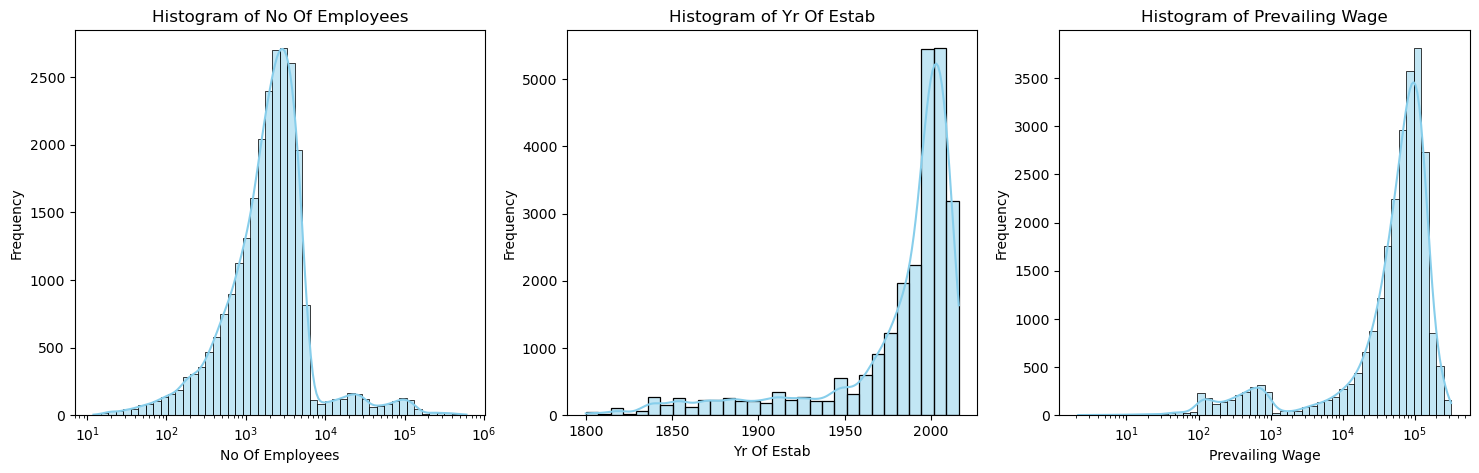

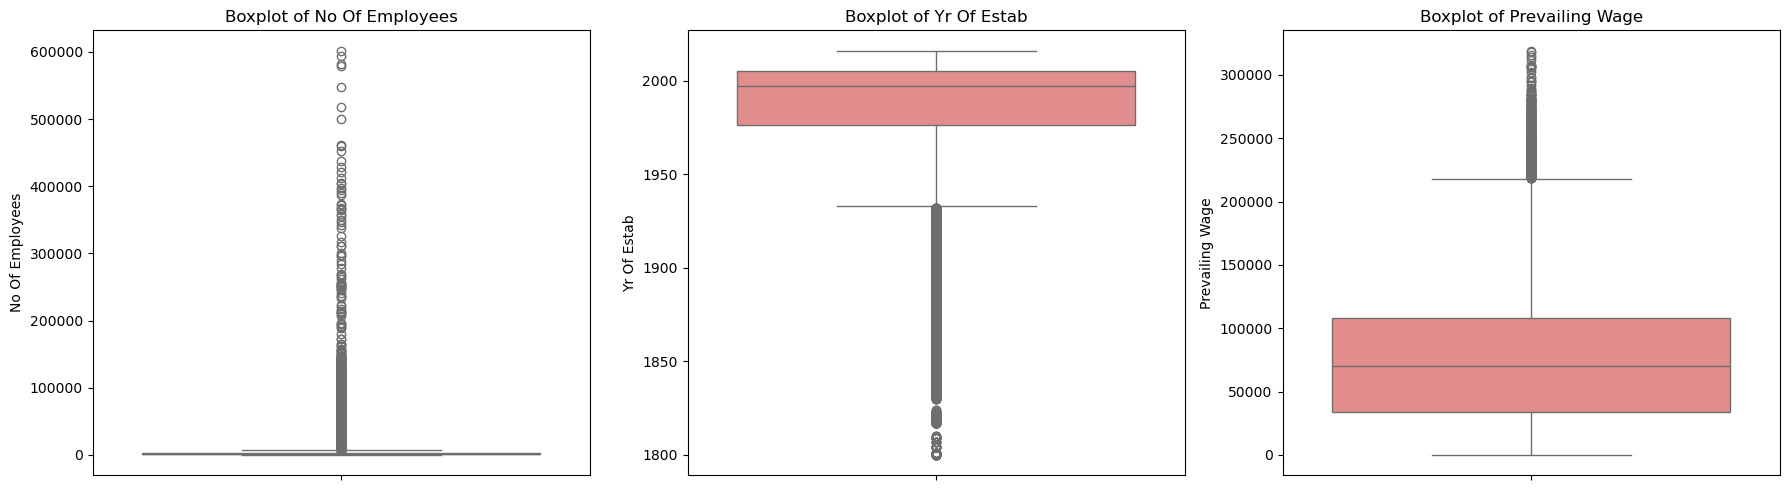

In [ ]:
# Numeric columns, Histogram and Boxplot
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(18, 5))

for i, col in enumerate(numeric_columns):
  plt.subplot(1, 3, i + 1)
  if col in ['no_of_employees', 'prevailing_wage']:
    sns.histplot(data[col], kde=True, bins=50, log_scale=True, color='skyblue')
  else:
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')

  plt.title(f'Histogram of {col.replace("_", " ").title()}', fontsize=12)
  plt.xlabel(col.replace("_", " ").title(), fontsize=10)
  plt.ylabel('Frequency', fontsize=10)


# Boxplot
plt.figure(figsize=(18, 5))
for i, col in enumerate(numeric_columns):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=data[col], color='lightcoral')
    plt.title(f'Boxplot of {col.replace("_", " ").title()}', fontsize=12)
    plt.ylabel(col.replace("_", " ").title(), fontsize=10)

plt.tight_layout()
plt.show()


- No of Employees: The distribution is heavily skewed toward smaller companies. The vast majority of employers have fewer than 10,000 employees.
- All three columns show a significant number of extreme outliers.
- Prevailing Wage: The interquartile range is relatively small, with the median close to the center, but the sheer scale of the outliers suggests a few very highly paid positions.

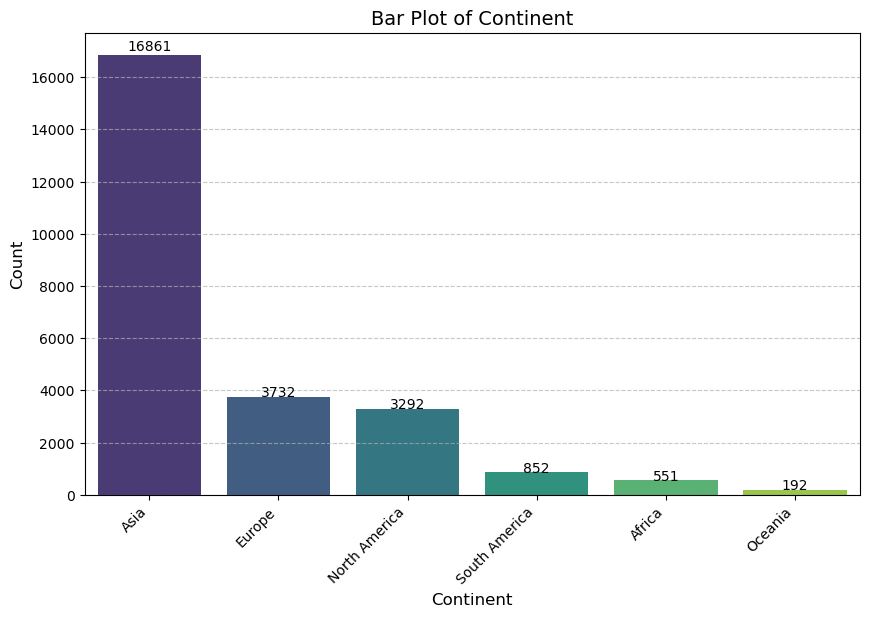

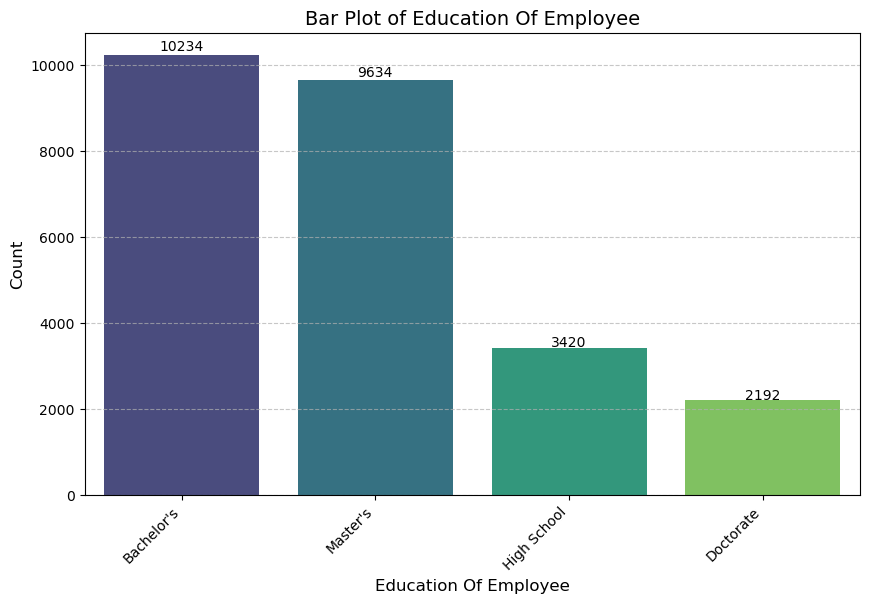

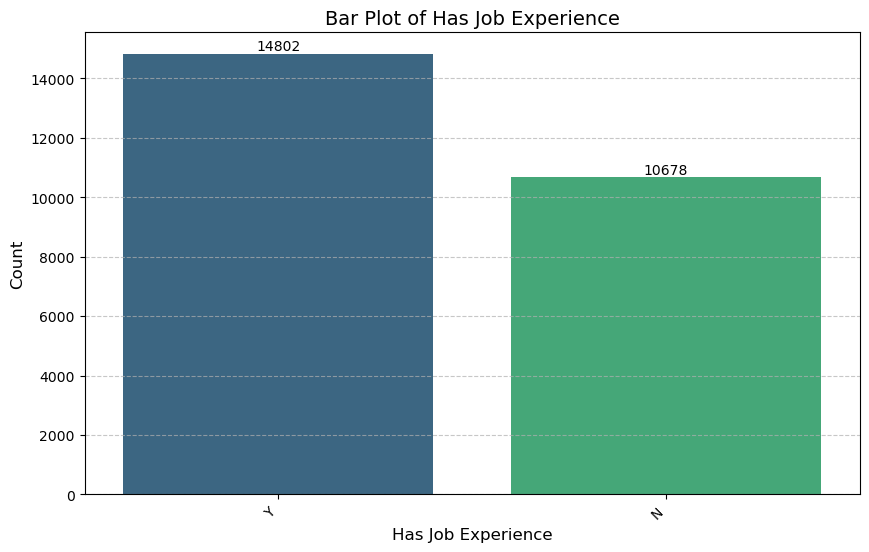

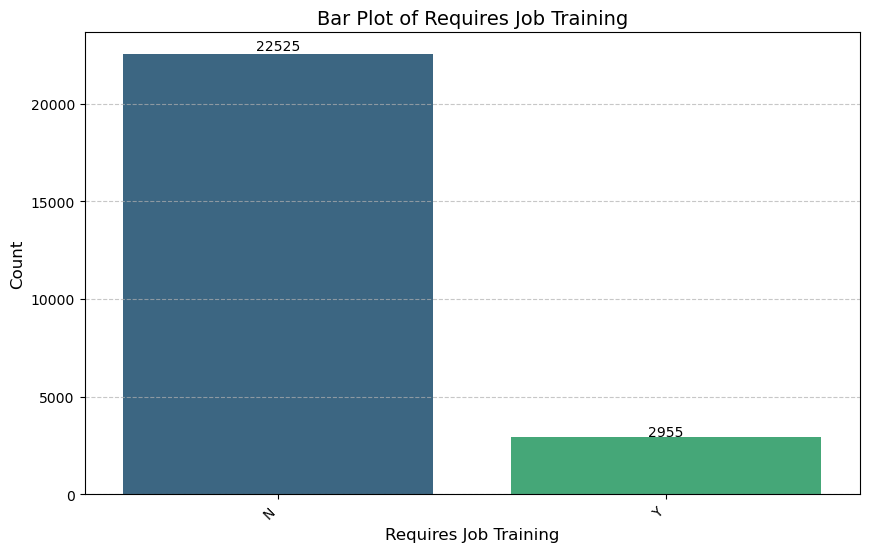

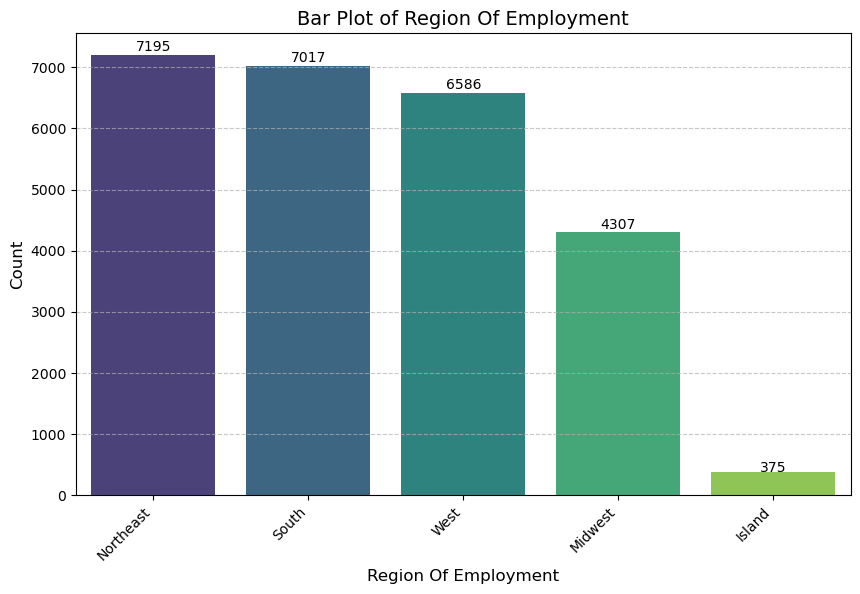

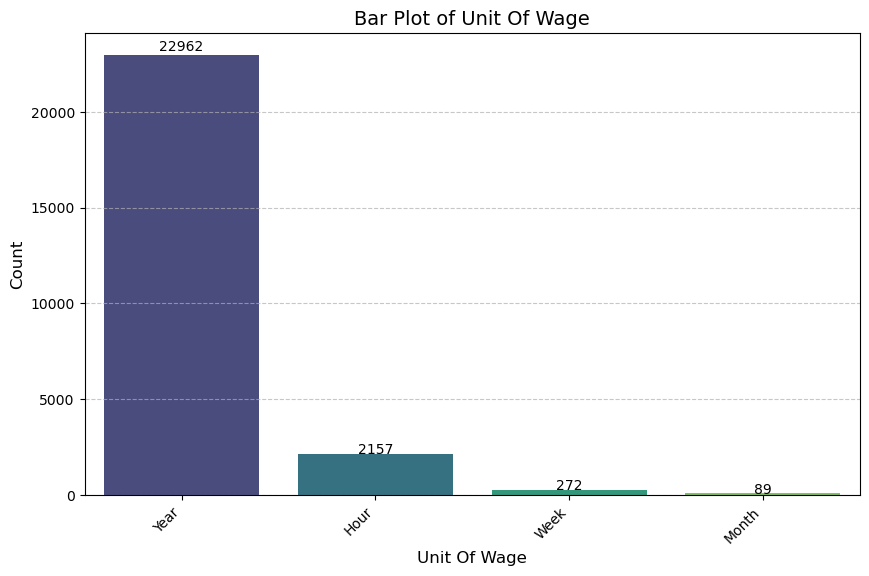

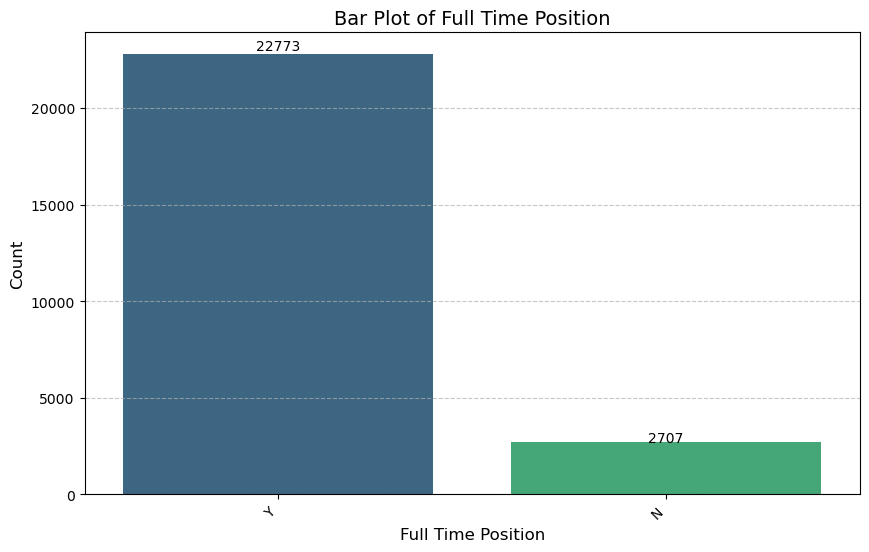

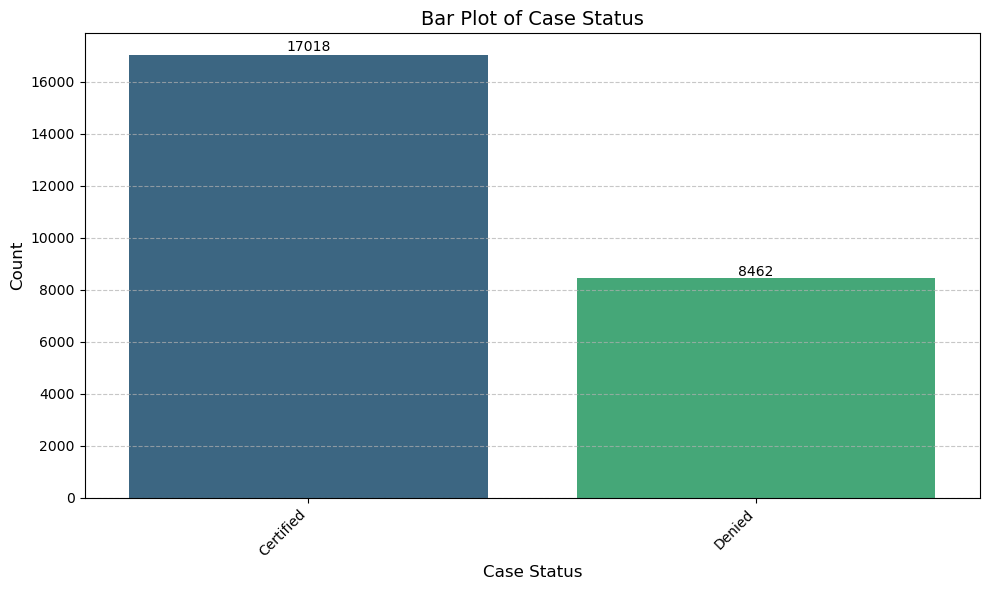

In [ ]:
# Categorical Analysis (Labeled Bar Plots)
categorical_columns = data.select_dtypes(include='object').columns.tolist()
for col in categorical_columns:
    plt.figure(figsize=(10, 6))

    # Calculate value counts and sort them by count
    count_data = data[col].value_counts().sort_values(ascending=False)

    # Create the bar plot
    sns.barplot(x=count_data.index, y=count_data.values, palette='viridis')

    # Add labels to the bars
    for index, value in enumerate(count_data.values):
        # Position the text slightly above the bar
        plt.text(index, value + (value * 0.01), f'{value}', ha='center')

    # Formatting
    plt.title(f'Bar Plot of {col.replace("_", " ").title()}', fontsize=14)
    plt.xlabel(col.replace("_", " ").title(), fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.close()

#### Observations on case status
- Certified is the majority outcome, accounting for 17,018 cases, compared to 8,462 Denied cases.

#### Observations on Continent
- Asia is the dominant continent by a large margin, with 16,861 applications. Europe is the second largest, with 3,726 applications.

#### Observations on education of employee
- The most common education level is Bachelor's (10,234), followed by Master's (6,692).

#### Observations on job experience
- More employees have job experience (Y: 14,902) than those who don't (N: 10,578).

#### Observations on Job Training
- A vast majority of cases do not require job training (N: 22,525), while only 2,955 do (Y).

#### Observations on region of employment
- The Northeast region has the highest number of applications (7,195), followed by the South (6,915).

#### Observations on Unit of Wage
- The Year is the most common unit of wage (22,982), indicating that most prevailing wages provided are annual salaries.

#### Observations on Full Time Position
- The vast majority of applications are for full-time positions (Y: 22,773), with only 2,707 being for non-full-time positions.

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [ ]:
# Def function to plot distributions wrt to target
def distribution_plot_wrt_target(data, predictor, target):
  """
   Generates a 2x2 grid plot showing:
    1. Histogram of the predictor for the first target class (Log-transformed for skewed data).
    2. Histogram of the predictor for the second target class (Log-transformed for skewed data).
    3. Boxplot of the predictor vs. the target (with outliers).
    4. Boxplot of the predictor vs. the target (without outliers).
  """
  sns.set_style('whitegrid')

  fig, axs = plt.subplots(2, 2, figsize=(14, 12))
  plt.subplots_adjust(hspace=0.4, wspace=0.3)

  target_uniq = data[target].unique()

  # Determine if log transformation is needed for histograms
  log_transform = predictor in ['no_of_employees', 'prevailing_wage']

  # Loop through the two target classes for Histograms
  for i, target_val in enumerate(target_uniq):
    ax = axs[0, i]
    ax.set_title(f'Distribution of {predictor}\nfor {target}={target_val}', fontsize=14)

    if log_transform:
      # Filter non-positive values and apply log(1+x)
      data_hist = data[data[target] == target_val].copy()
      data_hist = data_hist[data_hist[predictor] > 0]
      sns.histplot(
          x=np.log1p(data_hist[predictor]),
          kde=True,
          ax=ax,
          color=["teal", "orange"][i],
          stat="density",
      )
      ax.set_xlabel(f"Log(1 + {predictor})", fontsize=12)
    else:
      # Use normal linear scale
      sns.histplot(
          data=data[data[target] == target_val],
          x=predictor,
          kde=True,
          ax=ax,
          color=["teal", "orange"][i],
          stat="density",
      )
      ax.set_xlabel(predictor, fontsize=12)

    # Boxplot with outliers w.r.t target
    axs[1, 0].set_title(f"Boxplot w.r.t {target} (Outliers Included)", fontsize=14)
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    # Boxplot without outliers w.r.t target
    axs[1, 1].set_title(f"Boxplot w.r.t {target} (Outliers Excluded)", fontsize=14)
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

  plt.tight_layout()
  plt.show()


In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart showing distribution
    of the target variable across categories of the predictor variable.

    Parameters:
    data: pd.DataFrame
    predictor: str - name of the categorical independent variable
    target: str - name of the target variable (categorical)
    """

    # --- Frequency table ---
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]

    # Absolute counts
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print("📊 Absolute Counts by Category:")
    print(tab1)
    print("-" * 120)

    # Normalized (percentage)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    print("📈 Normalized Distribution by Category:")
    print(tab)
    print("-" * 120)

    # --- Plotting ---
    plt.figure(figsize=(max(count + 4, 10), 5))
    tab.plot(kind="bar", stacked=True, figsize=(max(count + 4, 10), 5), colormap="Set2")
    plt.title(f"Stacked Barplot: {predictor} vs {target}", fontsize=14)
    plt.xlabel(predictor)
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")

    # Place legend cleanly to the side
    plt.legend(title=target, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
    plt.tight_layout()
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

📊 Absolute Counts by Category:
case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------
📈 Normalized Distribution by Category:
case_status            Certified    Denied
education_of_employee                     
High School             0.340351  0.659649
Bachelor's              0.622142  0.377858
Master's                0.786278  0.213722
Doctorate               0.872263  0.127737
------------------------------------------------------------------------------------------------------------------------


<Figure size 1000x500 with 0 Axes>

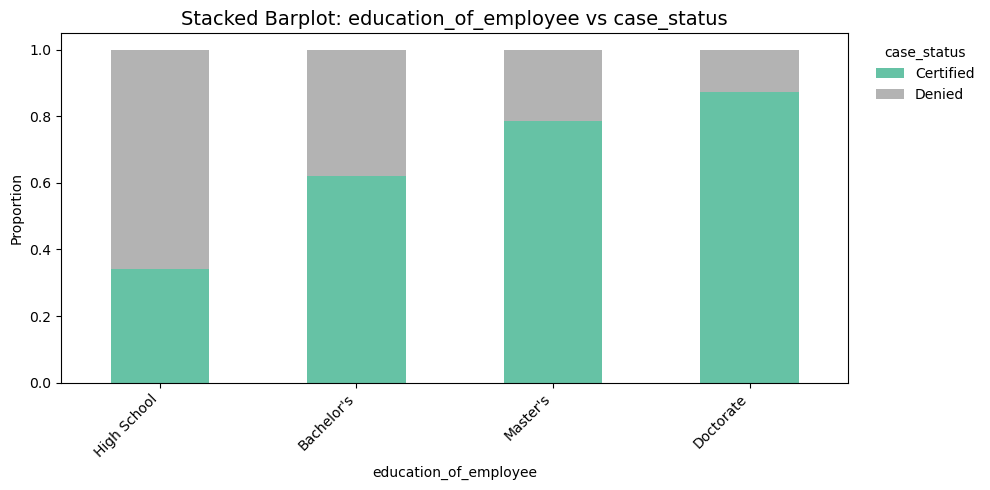

In [ ]:
stacked_barplot(data, predictor='education_of_employee', target='case_status')

- Yes, higher education significantly increases the chances of visa certification even for well-paid jobs.
- There is a clear positive correlation between education level and visa certification rate.
- Certification likelihood more than doubles from High School (34%) to Doctorate (87%).
- Each additional education level significantly increases success probability.

#### How does visa status vary across different continents?

📊 Absolute Counts by Category:
case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------
📈 Normalized Distribution by Category:
case_status    Certified    Denied
continent                         
South America   0.578638  0.421362
North America   0.618773  0.381227
Oceania         0.635417  0.364583
Asia            0.653105  0.346895
Africa          0.720508  0.279492
Europe          0.792337  0.207663
------------------------------------------------------------------------------------------------------------------------


<Figure size 1000x500 with 0 Axes>

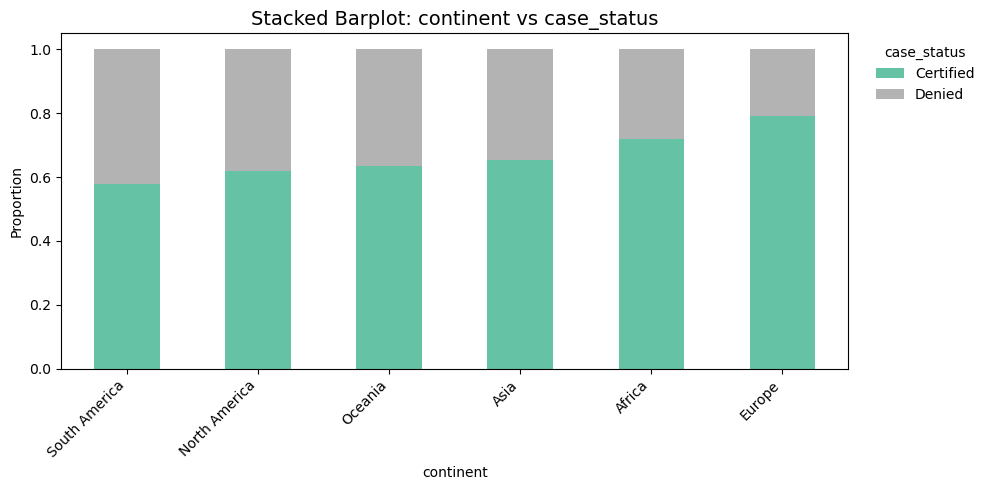

In [ ]:
stacked_barplot(data, predictor='continent', target='case_status')

- Applicants from Europe and Africa appear to have higher certification success rates.
- Asia follow closely, showing healthy approval rates.
- South America has the lowest certification ratio, indicating more denials or possibly less-qualified applications.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

📊 Absolute Counts by Category:
case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------
📈 Normalized Distribution by Category:
case_status         Certified    Denied
has_job_experience                     
N                    0.561341  0.438659
Y                    0.744764  0.255236
------------------------------------------------------------------------------------------------------------------------


<Figure size 1000x500 with 0 Axes>

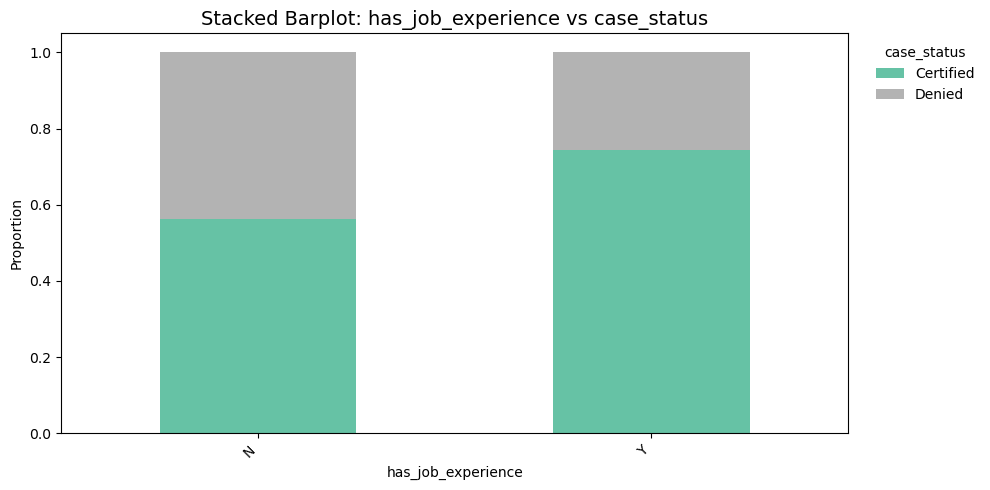

In [ ]:
stacked_barplot(data, predictor='has_job_experience', target='case_status')

- Applicants with prior work experience have a 33% higher likelihood of visa certification compared to those without experience.
- The effect is likely driven by stronger employer sponsorship, higher wages, and specialized job types.

#### Is the prevailing wage consistent across all regions of the US?

In [ ]:
region_wage_summary = data.groupby('region_of_employment')['prevailing_wage'].mean().sort_values(ascending=False)
print(region_wage_summary)

region_of_employment
Island       91712.750760
Midwest      91696.741794
South        74040.545216
West         69832.628698
Northeast    67872.662819
Name: prevailing_wage, dtype: float64


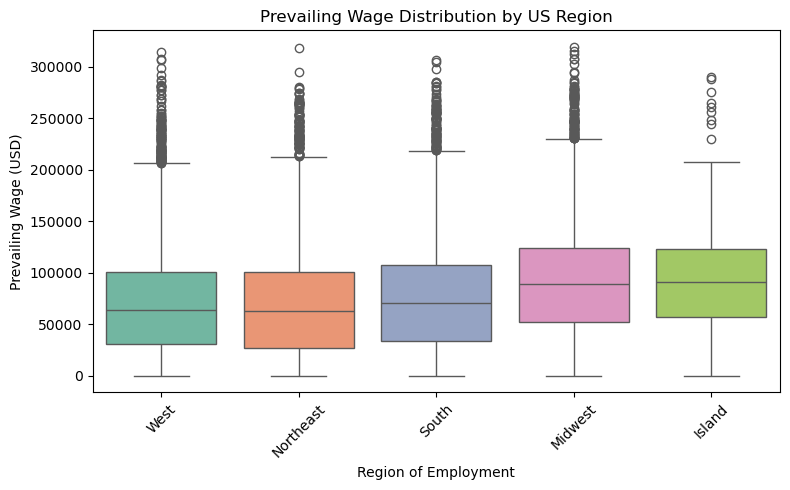

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='region_of_employment', y='prevailing_wage', palette='Set2')
plt.title('Prevailing Wage Distribution by US Region')
plt.xlabel('Region of Employment')
plt.ylabel('Prevailing Wage (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Prevailing wages are not consistent across all regions of the US.
- The highest average (mean) and median wages are observed in the Island and Midwest regions, while the Northeast region has the lowest.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

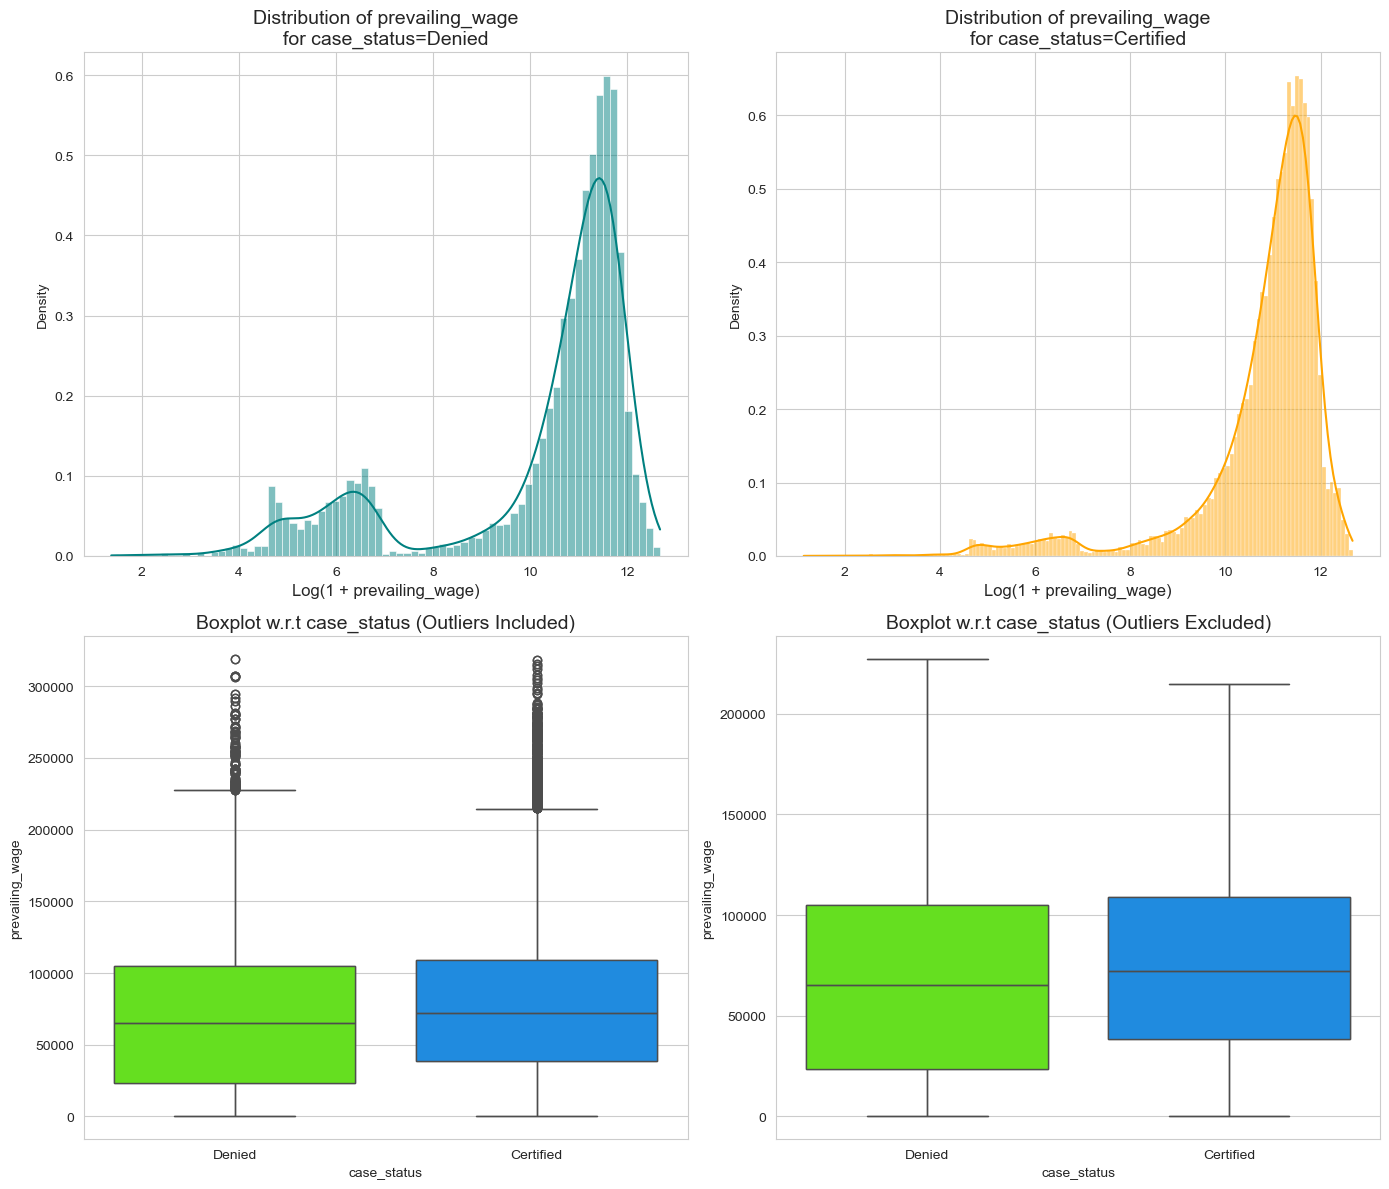

In [ ]:
distribution_plot_wrt_target(data, 'prevailing_wage', 'case_status')

- Visa status (certification) does vary significantly with the prevailing wage, and the observed pattern is consistent with the goal of protecting both local and foreign workers.
- The median prevailing wage for Certified cases is consistently and noticeably higher than the median wage for Denied cases. This difference is one of the strongest predictors of visa outcome.
- By approving applications that meet or exceed the local prevailing wage, the system helps ensure that foreign workers are not exploited by being placed in underpaid jobs.

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

📊 Absolute Counts by Category:
case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------
📈 Normalized Distribution by Category:
case_status   Certified    Denied
unit_of_wage                     
Hour           0.346314  0.653686
Month          0.617978  0.382022
Week           0.621324  0.378676
Year           0.698850  0.301150
------------------------------------------------------------------------------------------------------------------------


<Figure size 1000x500 with 0 Axes>

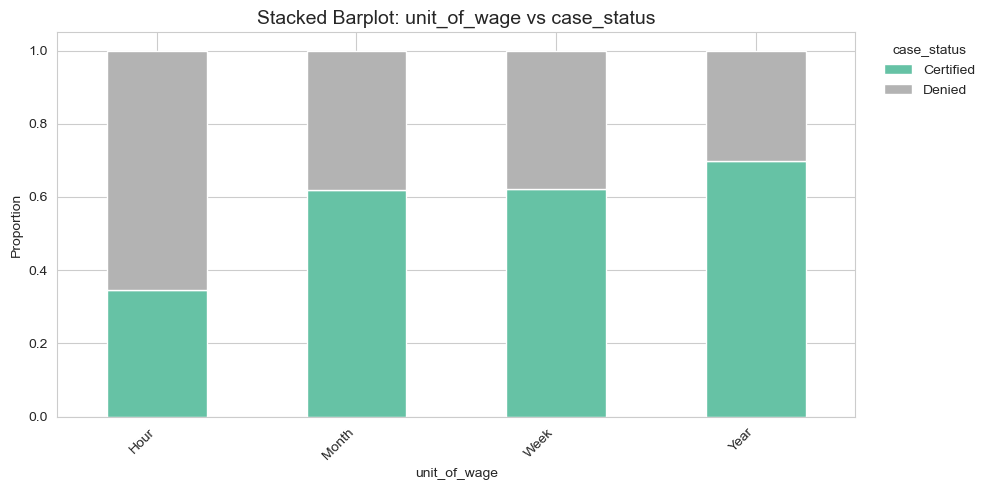

In [ ]:
stacked_barplot(data, predictor='unit_of_wage', target='case_status')

- The unit of prevailing wage has a major impact on visa certification likelihood
- Yearly salaries show the highest approval rate (70%), reflecting long-term, professional jobs with consistent pay.
- Hourly wage applications have less than half the success rate of annual salaries.

#### Does the employee count have any impact on the likelihood of visa application certification?

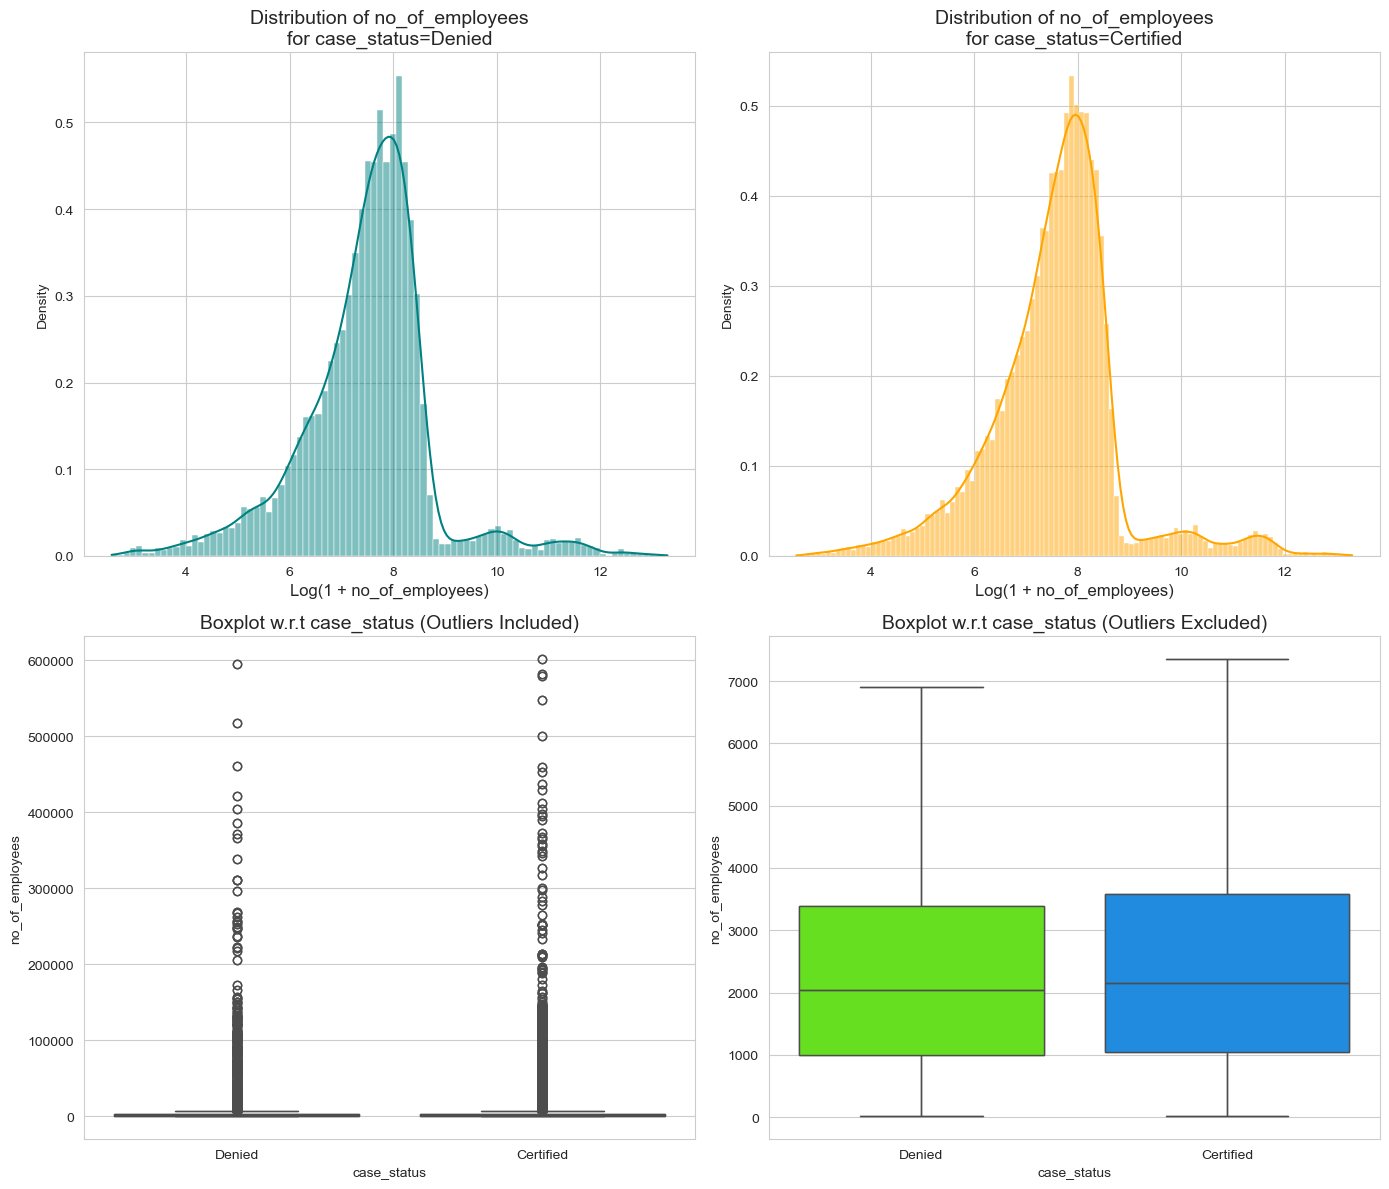

In [ ]:
distribution_plot_wrt_target(data, 'no_of_employees', 'case_status')

- The employee count of the sponsoring company does not appear to have a strong, differentiating impact on the likelihood of visa application certification.
- Both distributions are heavily concentrated at the lower end (small to medium-sized employers).
- The median employee count for Certified applications is almost the same as for Denied applications.

#### Does the age of the company have any impact on the likelihood of visa application certification?

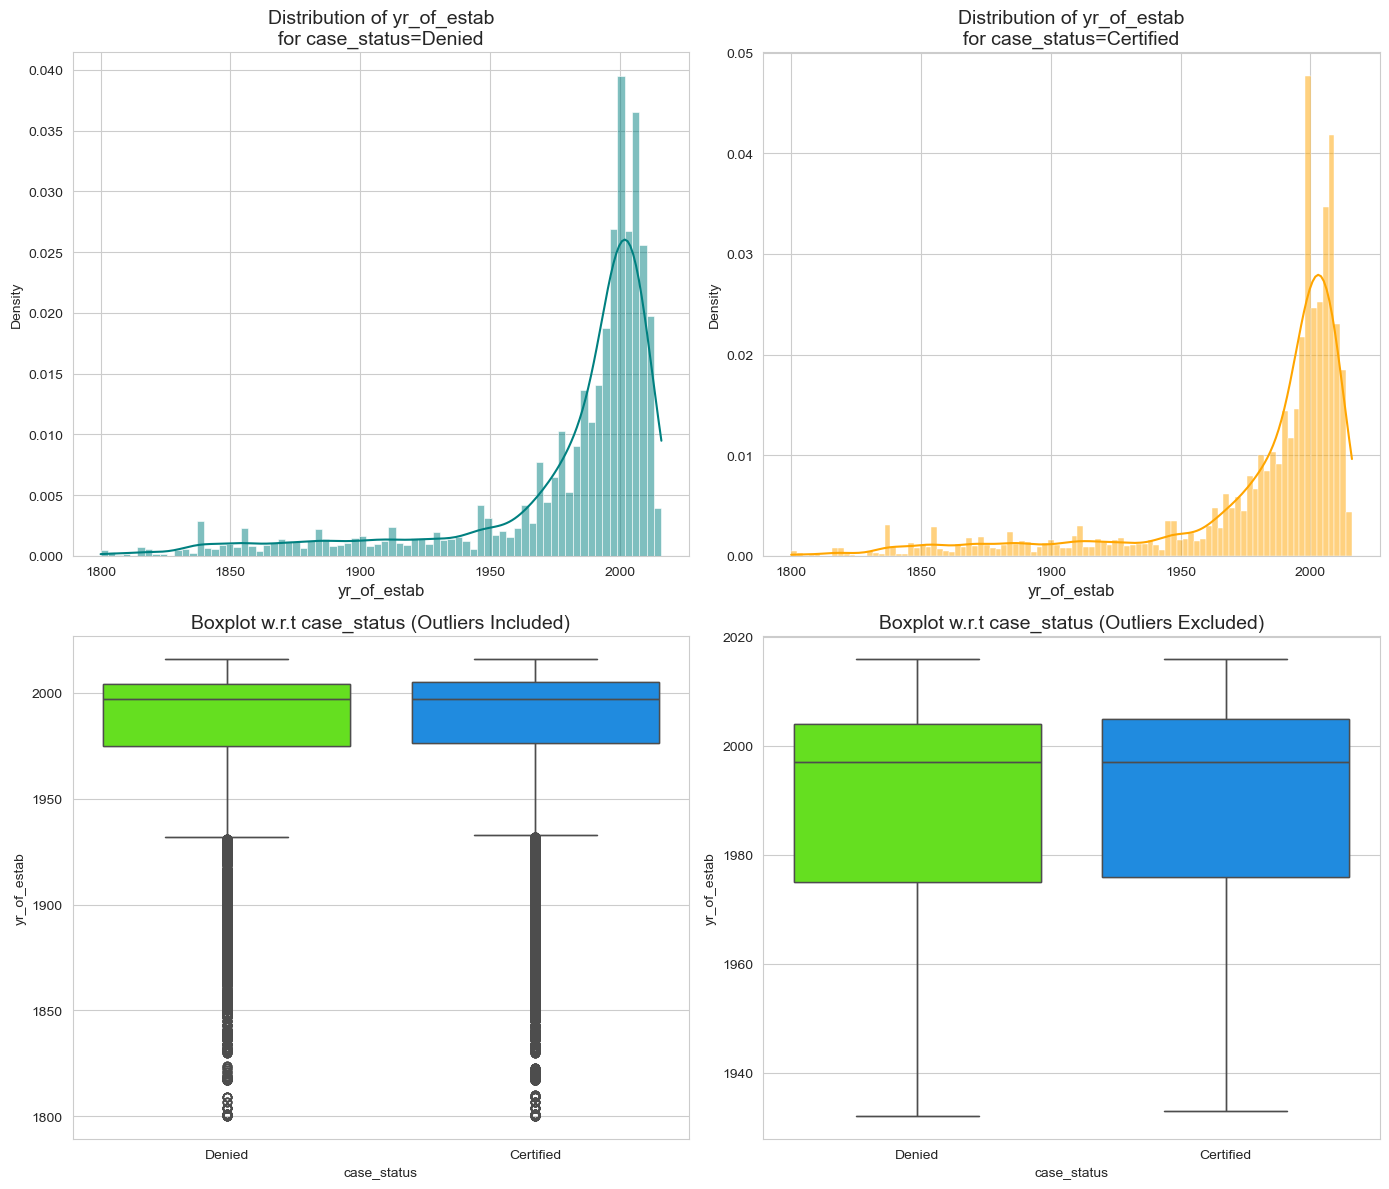

In [ ]:
distribution_plot_wrt_target(data, 'yr_of_estab', 'case_status')

- the age of the company does have an impact on the likelihood of visa application certification, though the difference is subtle. Newer companies show a slight advantage in obtaining certification compared to older companies.
- The distribution for certified cases is slightly more concentrated towards the recent years (the right side of the histogram). This indicates a larger volume of successful applications originating from companies founded in the late 1990s and 2000s.

## Data Pre-processing

### Splitting the data into X and y

In [ ]:
# Encode Target
data['case_status'] = data['case_status'].map({'Certified': 1, 'Denied': 0})

# separating the independent and dependent variables
X = data.drop('case_status', axis=1)
y = data['case_status']

# Splitting data into training, validation and test set:
# Split First: 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

# Split Second: 50% Validation, 50% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=0)

# Reset indices for clean data processing and create copies
X_train = X_train.copy().reset_index(drop=True)
X_val = X_val.copy().reset_index(drop=True)
X_test = X_test.copy().reset_index(drop=True)


### Outlier Check

In [ ]:
# Define function to cap outliers
def cap_outliers_split(data, column, lower, upper):
  data[column] = np.where(data[column] < lower, lower,
                          np.where(data[column] > upper, upper, data[column]))
  return data

### Data Preparation for modeling

#### Feature Engineering

In [ ]:
# Define conversion factors
conversion_factors = {'Year': 1, 'Month': 12, 'Week': 52, 'Hour': 2080}

def feature_engineer_and_clean(data_split, is_train=False, employee_median=None):
  data_split['company_age'] = 2025 - data_split['yr_of_estab']
  data_split['annual_wage'] = data_split.apply(
      lambda row: row['prevailing_wage'] * conversion_factors[row['unit_of_wage']],
      axis=1
  )

  data_split.drop(columns=['prevailing_wage','yr_of_estab','unit_of_wage'], inplace=True)

  # Outlier Imputation
  if is_train:
    employee_median = data_split.loc[data_split['no_of_employees'] >= 0, 'no_of_employees'].median()
  else:
    # Use provided median for validation and test sets
    if employee_median is None:
        raise ValueError("employee_median must be provided for validation and test sets.")

  # Impute negative values (outliers) using the calculated/provided median
  data_split['no_of_employees'] = np.where(data_split['no_of_employees'] < 0, employee_median, data_split['no_of_employees'])
  # Impute NaN values using the calculated/provided median
  data_split['no_of_employees'].fillna(employee_median, inplace=True)

  if is_train:
    return data_split, employee_median
  else:
    return data_split

# Apply to all splits
X_train, median_train = feature_engineer_and_clean(X_train, is_train=True)
X_val = feature_engineer_and_clean(X_val, is_train=False, employee_median=median_train)
X_test = feature_engineer_and_clean(X_test, is_train=False, employee_median=median_train)


#### Data Encoding and Final Preparation

In [ ]:
# Outlier capping
numerical_capping_cols = ['no_of_employees', 'annual_wage']
capping_boundaries = {}

# Learn boundaries ONLY from the training set
for col in numerical_capping_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capping_boundaries[col] = {'lower': lower, 'upper': upper}

    # Apply capping to X_train immediately
    X_train = cap_outliers_split(X_train, col, lower, upper)



In [ ]:
# Apply the learned boundaries to Validation and Test sets
for col in numerical_capping_cols:
    lower = capping_boundaries[col]['lower']
    upper = capping_boundaries[col]['upper']

    X_val = cap_outliers_split(X_val, col, lower, upper)
    X_test = cap_outliers_split(X_test, col, lower, upper)

##### Encoding and Scaling

In [ ]:
numerical_scaling_cols = ['no_of_employees', 'annual_wage', 'company_age']
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# One-Hot Encoding and Column Alignment
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

train_cols = X_train_encoded.columns.tolist()
X_val_final = X_val_encoded.reindex(columns=train_cols, fill_value=0)
X_test_final = X_test_encoded.reindex(columns=train_cols, fill_value=0)
X_train_final = X_train_encoded # X_train is the reference

# Standardization/Scaling
scaler = StandardScaler()
scaler.fit(X_train_final[numerical_scaling_cols])

# Apply the learned scaler to all splits
X_train_final[numerical_scaling_cols] = scaler.transform(X_train_final[numerical_scaling_cols])
X_val_final[numerical_scaling_cols] = scaler.transform(X_val_final[numerical_scaling_cols])
X_test_final[numerical_scaling_cols] = scaler.transform(X_test_final[numerical_scaling_cols])


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute key performance metrics for a classification model
    """

    # Predictions
    pred = model.predict(predictors)

    # Compute metrics
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    # Compile into DataFrame
    df_perf = pd.DataFrame({
        "Accuracy": [acc],
        "Recall": [recall],
        "Precision": [precision],
        "F1": [f1]
    })

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    Plot confusion matrix with raw counts and percentages
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    labels = np.asarray([
        [f"{v}\n{v/cm.sum():.2%}" for v in row] for row in cm
    ])

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="YlGnBu", cbar=False)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title("Confusion Matrix")
    plt.show()

#### Defining scorer to be used for cross-validation and hyperparameter tuning

- The most appropriate primary metric to evaluate the visa certification model is the F1-Score.
- Imbalanced Data: The dataset is typically imbalanced (more Certified cases than Denied cases). Accuracy is a misleading metric in imbalanced scenarios, as a model that predicts "Certified" for every case might still achieve high accuracy.
- Precision (Minimizing False Approvals): High precision ensures that when the model predicts a visa will be Certified, it is highly likely to be correct. Low precision here would lead to processing time wasted on applications that will ultimately be denied (False Positives).
- Recall (Minimizing False Denials): High recall ensures that the model correctly identifies most of the visas that should be Certified. Low recall would mean the model falsely denies high-quality applications (False Negatives), negatively impacting businesses and talented applicants.

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [ ]:
# models without hyperparameter tuning
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Bagging": BaggingClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "AdaBoost": AdaBoostClassifier(random_state=1)
}

#### Model's performance

In [ ]:
# Model's performance on training & validation data
train_results = {}
val_results = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Train the model
    model.fit(X_train_final, y_train)

    # Evaluate on Training Set
    train_performance = model_performance_classification_sklearn(model, X_train_final, y_train)
    train_results[name] = train_performance.iloc[0].to_dict()

    print(f"Training Performance:")
    print(train_results[name])
    print("\n")

    # Evaluate on Validation Set
    val_performance = model_performance_classification_sklearn(model, X_val_final, y_val)
    val_results[name] = val_performance.iloc[0].to_dict()

    print(f"Validation Performance:")
    print(val_results[name])
    print("\n")

Training Decision Tree...
Training Performance:
{'Accuracy': 0.999943933617403, 'Recall': 0.9999160580878033, 'Precision': 1.0, 'F1': 0.9999580272822666}


Validation Performance:
{'Accuracy': 0.6462585034013606, 'Recall': 0.7399138268703486, 'Precision': 0.73302289483896, 'F1': 0.7364522417153996}


Training Bagging...
Training Performance:
{'Accuracy': 0.9839650145772595, 'Recall': 0.9856459330143541, 'Precision': 0.9903010879649152, 'F1': 0.987968026924695}


Validation Performance:
{'Accuracy': 0.69570905285191, 'Recall': 0.7806502154328241, 'Precision': 0.7677195685670262, 'F1': 0.7741308992037289}


Training Random Forest...
Training Performance:
{'Accuracy': 0.999887867234806, 'Recall': 1.0, 'Precision': 0.999832144355854, 'F1': 0.9999160651334564}


Validation Performance:
{'Accuracy': 0.7116692830978545, 'Recall': 0.8335291813552683, 'Precision': 0.7586452762923351, 'F1': 0.7943262411347518}


Training Gradient Boosting...
Training Performance:
{'Accuracy': 0.7475330791657322,

Confusion Matrix for Decision Tree on Training Data:


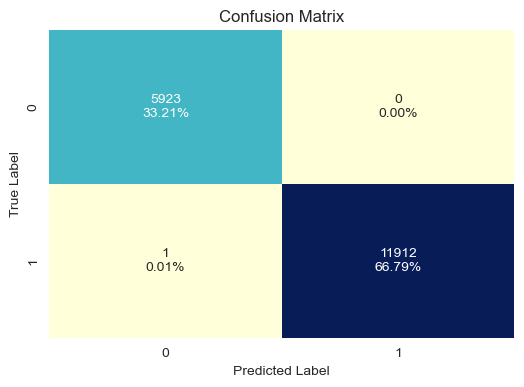

Confusion Matrix for Bagging on Training Data:


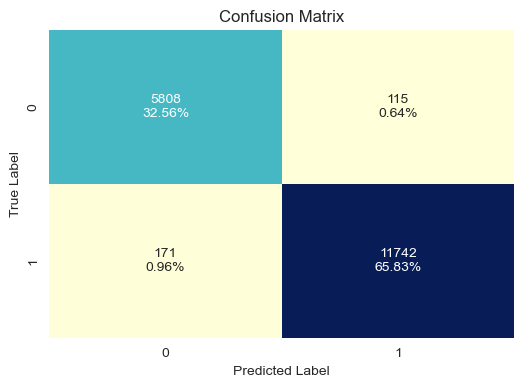

Confusion Matrix for Random Forest on Training Data:


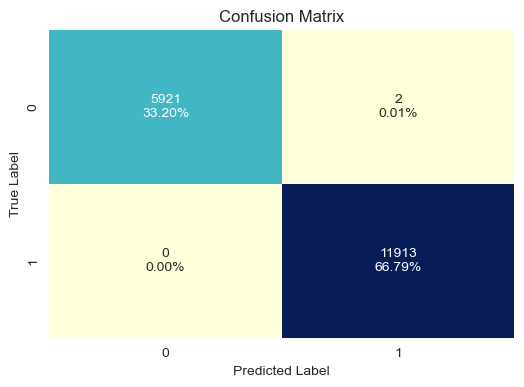

Confusion Matrix for Gradient Boosting on Training Data:


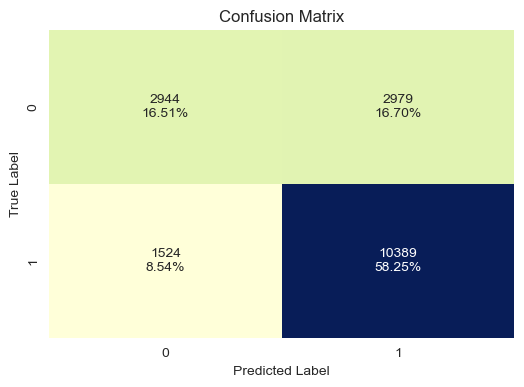

Confusion Matrix for AdaBoost on Training Data:


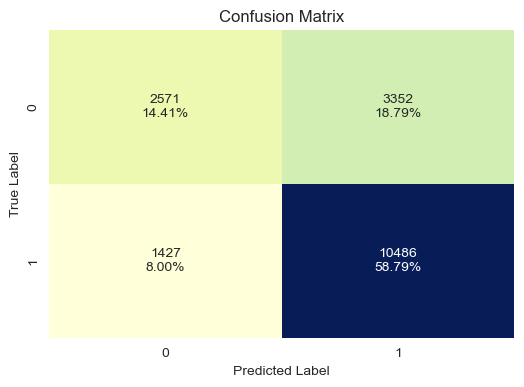

In [ ]:
# Confusion Matrix for training data
for name, model in models.items():
    print(f"Confusion Matrix for {name} on Training Data:")
    confusion_matrix_sklearn(model, X_train_final, y_train)

Confusion Matrix for Decision Tree on Validation Data:


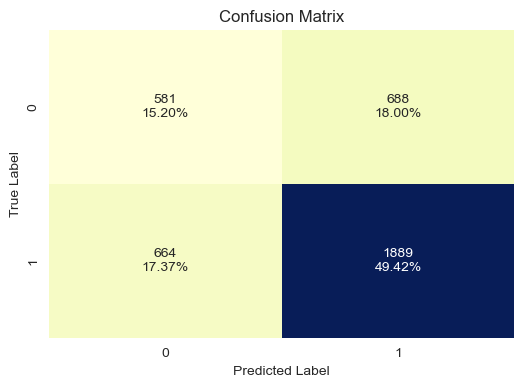

Confusion Matrix for Bagging on Validation Data:


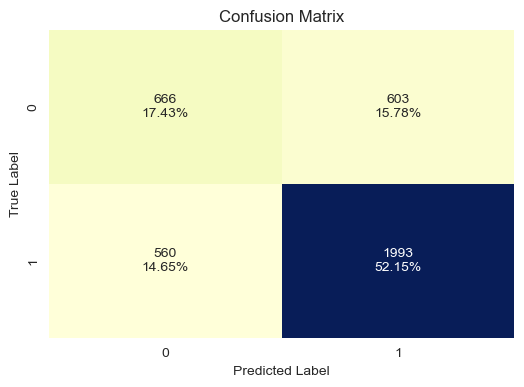

Confusion Matrix for Random Forest on Validation Data:


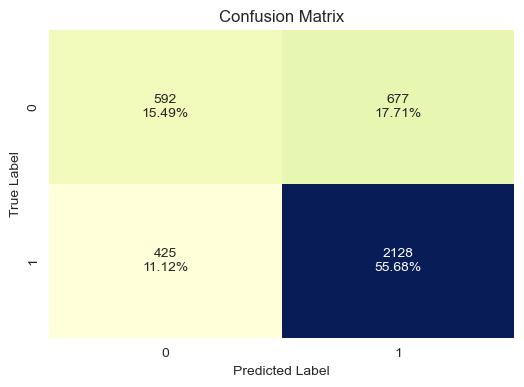

Confusion Matrix for Gradient Boosting on Validation Data:


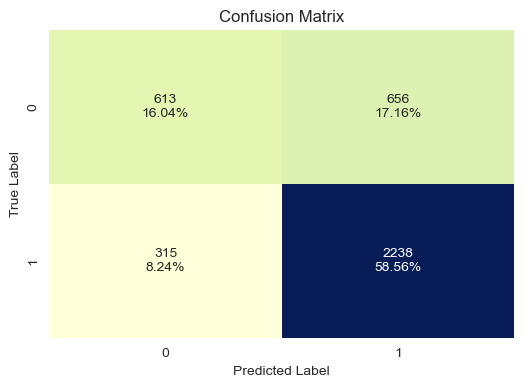

Confusion Matrix for AdaBoost on Validation Data:


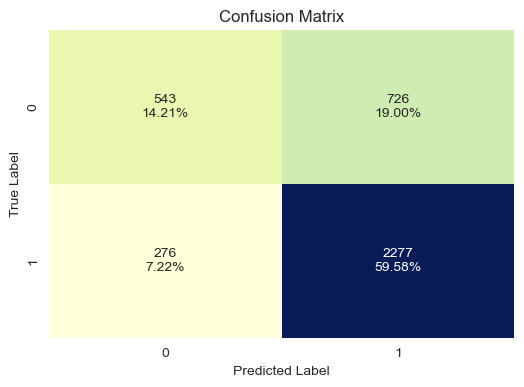

In [ ]:
# Confusion matrix for validation data
for name, model in models.items():
    print(f"Confusion Matrix for {name} on Validation Data:")
    confusion_matrix_sklearn(model, X_val_final, y_val)

In [ ]:
# Summarize and compare the results
df_train = pd.DataFrame(train_results).T
df_val = pd.DataFrame(val_results).T

# Comparison table
df_comparison = pd.concat([df_train['F1'].rename('Train F1'), df_val['F1'].rename('Validation F1')], axis=1)
df_comparison['F1 Difference (Train - Val)'] = df_comparison['Train F1'] - df_comparison['Validation F1']
df_comparison = df_comparison.sort_values(by='Validation F1', ascending=False)

print("\n--- Training and Validation Set Performance Comparison ---")
print(df_comparison.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))


--- Training and Validation Set Performance Comparison ---
|                   | Train F1   | Validation F1   | F1 Difference (Train - Val)   |
|:------------------|:-----------|:----------------|:------------------------------|
| Gradient Boosting | 0.8219     | 0.8217          | 0.0001                        |
| AdaBoost          | 0.8144     | 0.8197          | -0.0052                       |
| Random Forest     | 0.9999     | 0.7943          | 0.2056                        |
| Bagging           | 0.9880     | 0.7741          | 0.2138                        |
| Decision Tree     | 1.0000     | 0.7365          | 0.2635                        |


- Decision Tree, Bagging, and Random Forest have very high training F1 but significantly lower validation F1 — this is a clear sign of overfitting.
- Gradient Boosting and AdaBoost, on the other hand, have nearly identical Train and Validation F1 scores, indicating excellent generalization.
- The highest Validation F1 belongs to Gradient Boosting (0.8217), closely followed by AdaBoost (0.8197).
- Conclusion: The Gradient Boosting Classifier is the best model based on these baseline evaluations.

#### Applying SMOTE for Oversampling

In [ ]:
# Apply SMOTE only to the training data
smote = SMOTE(sampling_strategy=0.7, k_neighbors=5,random_state=RANDOM_STATE)
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train_final, y_train)

print("Shape of training data after Oversampling (SMOTE):")
print(X_train_oversampled.shape)
print(y_train_oversampled.shape)

print("\nClass distribution in training data after Oversampling:")
print(y_train_oversampled.value_counts())


Shape of training data after Oversampling (SMOTE):
(20252, 18)
(20252,)

Class distribution in training data after Oversampling:
case_status
1    11913
0     8339
Name: count, dtype: int64


#### Model building with Oversampled data

In [ ]:
# models with oversampling data
models_smote = {
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Bagging": BaggingClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "AdaBoost": AdaBoostClassifier(random_state=1)
}

In [ ]:
# Model's performance on oversampled training & validation data
train_results_oversampled = {}
val_results_oversampled = {}

for name, model in models_smote.items():
    print(f"Training {name}...")

    # Train the model
    model.fit(X_train_oversampled, y_train_oversampled)

    # Evaluate on Training Set Oversampled
    train_performance_oversampled = model_performance_classification_sklearn(model, X_train_oversampled, y_train_oversampled)
    train_results_oversampled[name] = train_performance_oversampled.iloc[0].to_dict()

    print(f"Training Performance Oversampled:")
    print(train_results_oversampled[name])
    print("\n")

    # Evaluate on Validation Set Oversampled
    val_performance_oversampled = model_performance_classification_sklearn(model, X_val_final, y_val)
    val_results_oversampled[name] = val_performance_oversampled.iloc[0].to_dict()

    print(f"Validation Performance Oversampled:")
    print(val_results_oversampled[name])
    print("\n")

Training Decision Tree...
Training Performance Oversampled:
{'Accuracy': 0.9999506221607742, 'Recall': 0.9999160580878033, 'Precision': 1.0, 'F1': 0.9999580272822666}


Validation Performance Oversampled:
{'Accuracy': 0.6480900052328624, 'Recall': 0.7171954563258911, 'Precision': 0.7461287693561532, 'F1': 0.7313760734971041}


Training Bagging...
Training Performance Oversampled:
{'Accuracy': 0.984445980643887, 'Recall': 0.9801057668093679, 'Precision': 0.9933639612046963, 'F1': 0.9866903283052352}


Validation Performance Oversampled:
{'Accuracy': 0.6763474620617478, 'Recall': 0.7336466901684293, 'Precision': 0.7707818930041153, 'F1': 0.7517559702990166}


Training Random Forest...
Training Performance Oversampled:
{'Accuracy': 0.9999506221607742, 'Recall': 0.9999160580878033, 'Precision': 1.0, 'F1': 0.9999580272822666}


Validation Performance Oversampled:
{'Accuracy': 0.7140240711669283, 'Recall': 0.8135526831179005, 'Precision': 0.7709725315515962, 'F1': 0.7916904898036974}


Train

Confusion Matrix for Decision Tree on Oversampled Training Data:


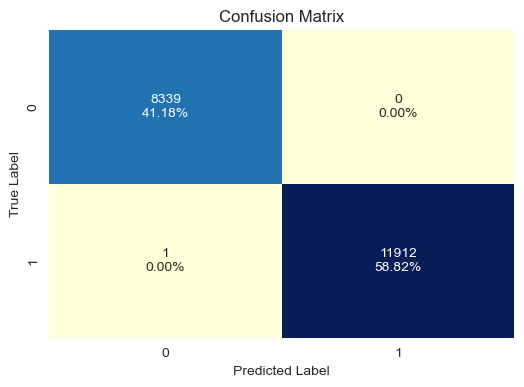

Confusion Matrix for Bagging on Oversampled Training Data:


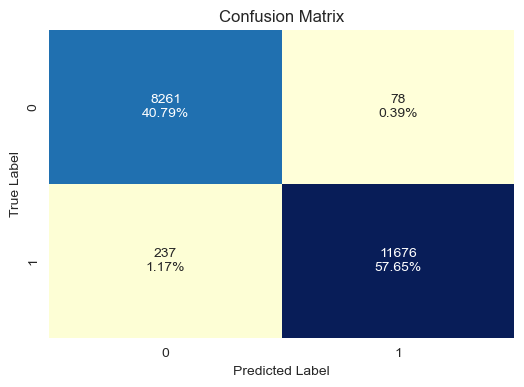

Confusion Matrix for Random Forest on Oversampled Training Data:


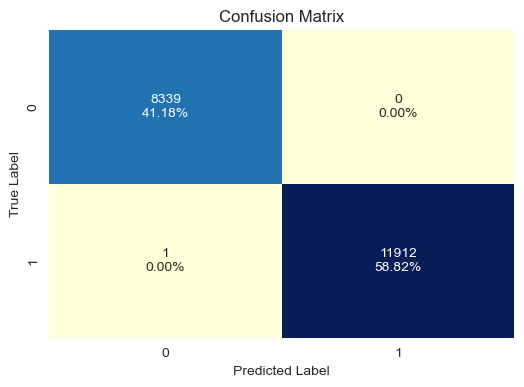

Confusion Matrix for Gradient Boosting on Oversampled Training Data:


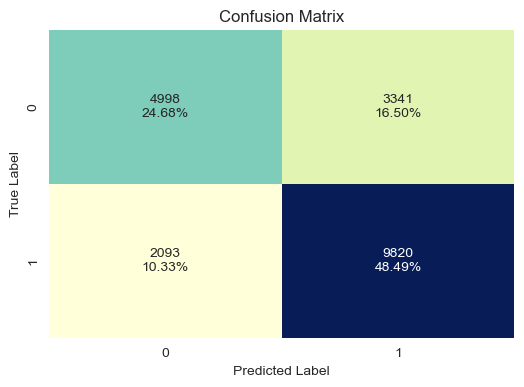

Confusion Matrix for AdaBoost on Oversampled Training Data:


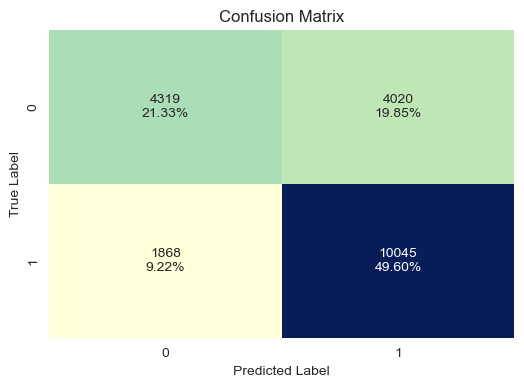

In [ ]:
# Confusion matrix for oversampled train data
for name, model in models_smote.items():
    print(f"Confusion Matrix for {name} on Oversampled Training Data:")
    confusion_matrix_sklearn(model, X_train_oversampled, y_train_oversampled)

Confusion Matrix for Decision Tree on Oversampled Validation Data:


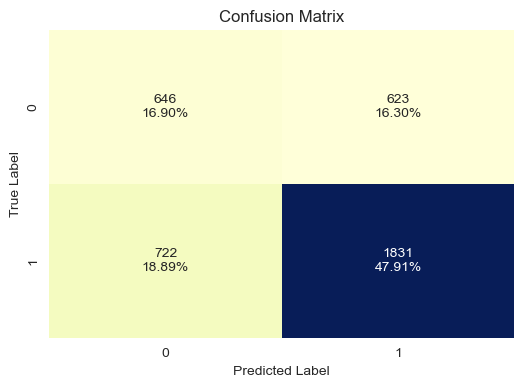

Confusion Matrix for Bagging on Oversampled Validation Data:


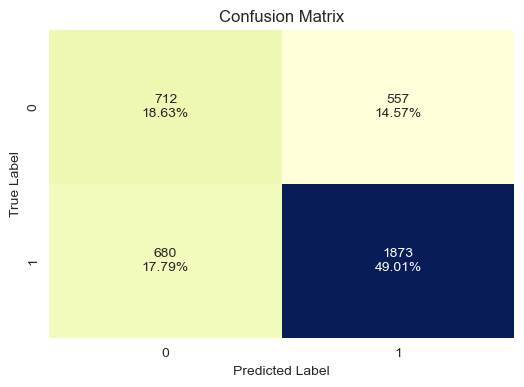

Confusion Matrix for Random Forest on Oversampled Validation Data:


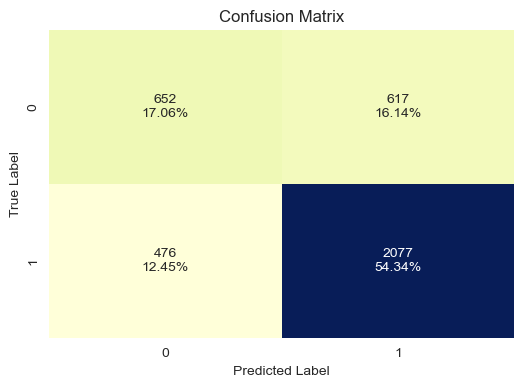

Confusion Matrix for Gradient Boosting on Oversampled Validation Data:


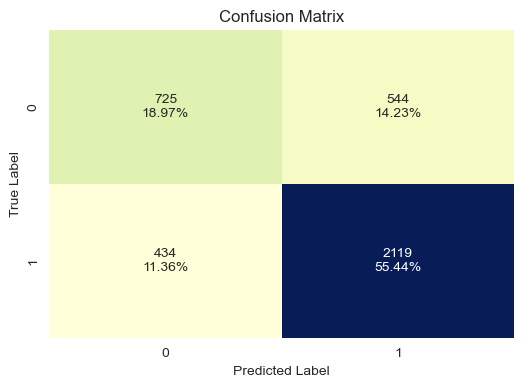

Confusion Matrix for AdaBoost on Oversampled Validation Data:


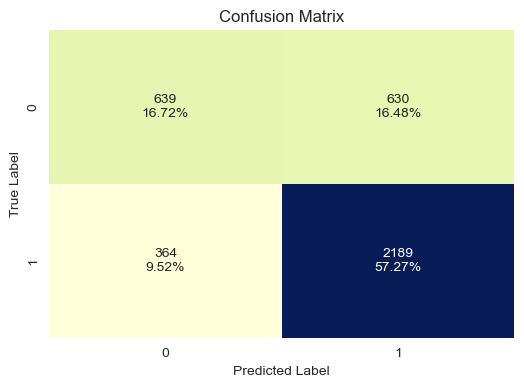

In [ ]:
# Confusion matrix for validation data
for name, model in models_smote.items():
    print(f"Confusion Matrix for {name} on Oversampled Validation Data:")
    confusion_matrix_sklearn(model, X_val_final, y_val)

In [ ]:
# Summarize and compare the results
df_train_oversampled = pd.DataFrame(train_results_oversampled).T
df_val_oversampled = pd.DataFrame(val_results_oversampled).T

# Comparison table
df_comparison_oversampled = pd.concat([df_train_oversampled['F1'].rename('Train F1'), df_val_oversampled['F1'].rename('Validation F1')], axis=1)
df_comparison_oversampled['F1 Difference (Train - Val)'] = df_comparison_oversampled['Train F1'] - df_comparison_oversampled['Validation F1']
df_comparison = df_comparison.sort_values(by='Validation F1', ascending=False)

print("\n--- Training and Validation Set Performance Comparison (Oversampled Data) ---")
print(df_comparison_oversampled.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))



--- Training and Validation Set Performance Comparison (Oversampled Data) ---
|                   | Train F1   | Validation F1   | F1 Difference (Train - Val)   |
|:------------------|:-----------|:----------------|:------------------------------|
| Decision Tree     | 1.0000     | 0.7314          | 0.2686                        |
| Bagging           | 0.9867     | 0.7518          | 0.2349                        |
| Random Forest     | 1.0000     | 0.7917          | 0.2083                        |
| Gradient Boosting | 0.7833     | 0.8125          | -0.0292                       |
| AdaBoost          | 0.7733     | 0.8150          | -0.0416                       |


- Decision Tree, Bagging, and Random Forest all show Train F1 approximately equal to 1.0, but Validation F1 < 0.80.
- Gradient Boosting: Train F1 = 0.7833, Val F1 = 0.8125 → small difference (–0.0292).
- AdaBoost: Train F1 = 0.7733, Val F1 = 0.8150 → small difference (–0.0416).
- boosting models handle the oversampled data without overfitting, and they actually perform better on unseen data.
- Both significantly outperform Bagging, Random Forest, and Decision Tree on validation data.


#### Applying RandomUnderSampler for Undersampling

In [ ]:
# Apply RandomUnderSampler only to the training data
rus = RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=1)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train_final, y_train)

print("Shape of training data after Undersampling (RandomUnderSampler):")
print(X_train_undersampled.shape)
print(y_train_undersampled.shape)

print("\nClass distribution in training data after Undersampling:")
print(y_train_undersampled.value_counts())


Shape of training data after Undersampling (RandomUnderSampler):
(11846, 18)
(11846,)

Class distribution in training data after Undersampling:
case_status
0    5923
1    5923
Name: count, dtype: int64


#### Model building with Undersampled data

In [ ]:
# models with undersampled data
models_under_sampler = {
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Bagging": BaggingClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "AdaBoost": AdaBoostClassifier(random_state=1)
}

In [ ]:
# Model's performance on undersampled training & validation data
train_results_undersampled = {}
val_results_undersampled = {}

for name, model in models_under_sampler.items():
    print(f"Training {name}...")

    # Train the model
    model.fit(X_train_undersampled, y_train_undersampled)

    # Evaluate on Training Set undersampled
    train_performance_undersampled = model_performance_classification_sklearn(model, X_train_undersampled, y_train_undersampled)
    train_results_undersampled[name] = train_performance_undersampled.iloc[0].to_dict()

    print(f"Training Performance undersampled:")
    print(train_results_undersampled[name])
    print("\n")

    # Evaluate on Validation Set undersampled
    val_performance_undersampled = model_performance_classification_sklearn(model, X_val_final, y_val)
    val_results_undersampled[name] = val_performance_undersampled.iloc[0].to_dict()

    print(f"Validation Performance undersampled:")
    print(val_results_undersampled[name])
    print("\n")

Training Decision Tree...
Training Performance undersampled:
{'Accuracy': 0.9999155833192639, 'Recall': 0.9998311666385278, 'Precision': 1.0, 'F1': 0.9999155761924863}


Validation Performance undersampled:
{'Accuracy': 0.6229722658294087, 'Recall': 0.63572267920094, 'Precision': 0.760543580131209, 'F1': 0.6925538724130574}


Training Bagging...
Training Performance undersampled:
{'Accuracy': 0.9798244133040689, 'Recall': 0.9669086611514435, 'Precision': 0.9925476603119584, 'F1': 0.97956042076456}


Validation Performance undersampled:
{'Accuracy': 0.641548927263213, 'Recall': 0.6102624363493929, 'Precision': 0.8060010346611485, 'F1': 0.6946054391440035}


Training Random Forest...
Training Performance undersampled:
{'Accuracy': 0.9999155833192639, 'Recall': 0.9998311666385278, 'Precision': 1.0, 'F1': 0.9999155761924863}


Validation Performance undersampled:
{'Accuracy': 0.6779173207744636, 'Recall': 0.6764590677634156, 'Precision': 0.8100375234521576, 'F1': 0.7372465314834579}


Trai

Confusion Matrix for Decision Tree on Undersampled Training Data:


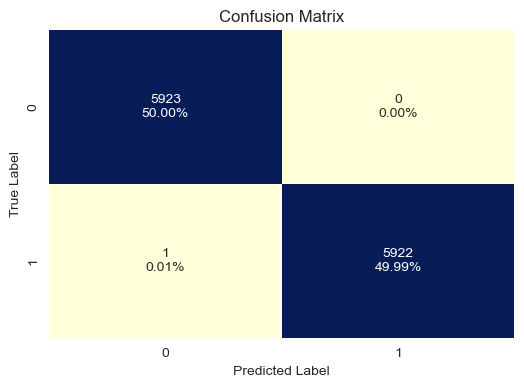

Confusion Matrix for Bagging on Undersampled Training Data:


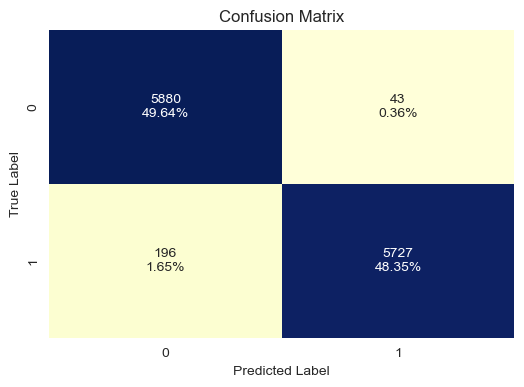

Confusion Matrix for Random Forest on Undersampled Training Data:


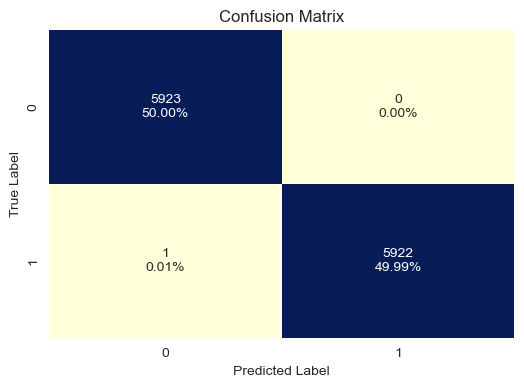

Confusion Matrix for Gradient Boosting on Undersampled Training Data:


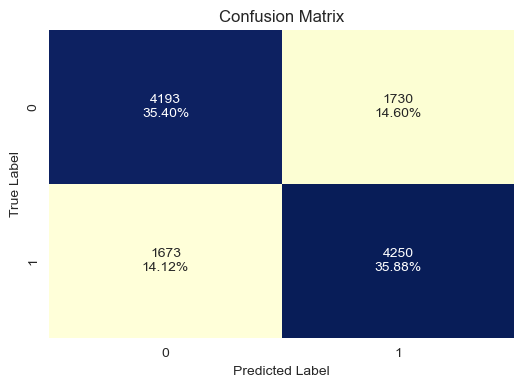

Confusion Matrix for AdaBoost on Undersampled Training Data:


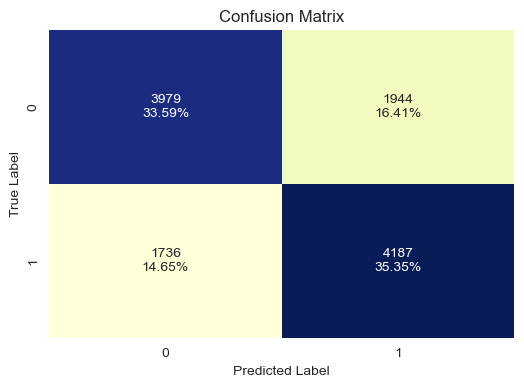

In [ ]:
# Confusion matrix for undersampled train data
for name, model in models_under_sampler.items():
    print(f"Confusion Matrix for {name} on Undersampled Training Data:")
    confusion_matrix_sklearn(model, X_train_undersampled, y_train_undersampled)

Confusion Matrix for Decision Tree on Undersampled Validation Data:


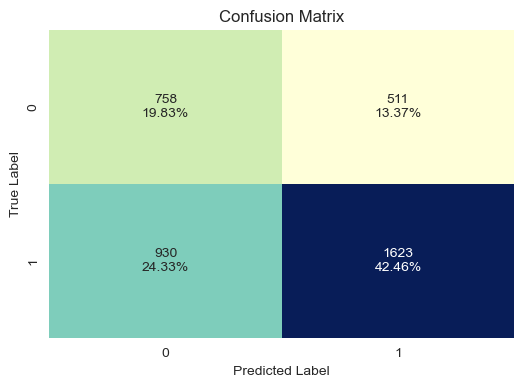

Confusion Matrix for Bagging on Undersampled Validation Data:


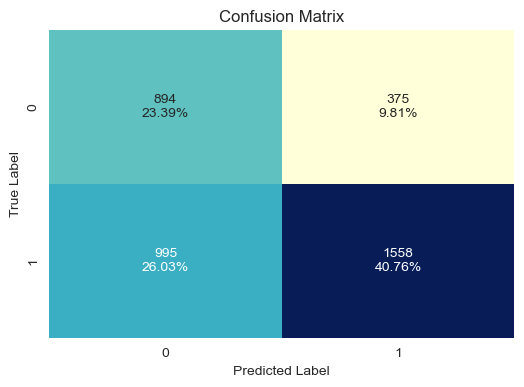

Confusion Matrix for Random Forest on Undersampled Validation Data:


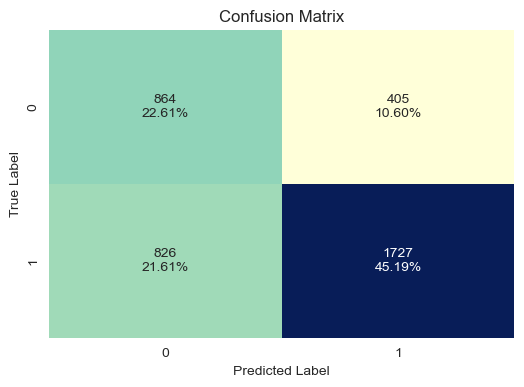

Confusion Matrix for Gradient Boosting on Undersampled Validation Data:


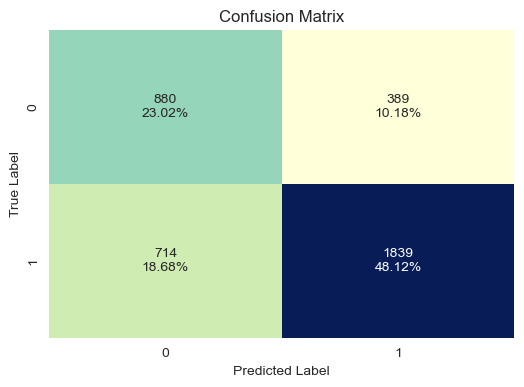

Confusion Matrix for AdaBoost on Undersampled Validation Data:


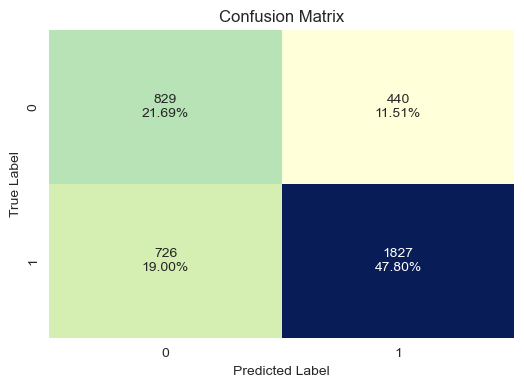

In [ ]:
# Confusion matrix for undersampled validation data
for name, model in models_under_sampler.items():
    print(f"Confusion Matrix for {name} on Undersampled Validation Data:")
    confusion_matrix_sklearn(model, X_val_final, y_val)

In [ ]:
# Summarize and compare the results
df_train_undersampled = pd.DataFrame(train_results_undersampled).T
df_val_undersampled = pd.DataFrame(val_results_undersampled).T

# Comparison table
df_comparison_undersampled = pd.concat([df_train_undersampled['F1'].rename('Train F1'), df_val_undersampled['F1'].rename('Validation F1')], axis=1)
df_comparison_undersampled['F1 Difference (Train - Val)'] = df_comparison_undersampled['Train F1'] - df_comparison_undersampled['Validation F1']
df_comparison = df_comparison.sort_values(by='Validation F1', ascending=False)

print("\n--- Training and Validation Set Performance Comparison (Undersampled Data) ---")
print(df_comparison_undersampled.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))


--- Training and Validation Set Performance Comparison (Undersampled Data) ---
|                   | Train F1   | Validation F1   | F1 Difference (Train - Val)   |
|:------------------|:-----------|:----------------|:------------------------------|
| Decision Tree     | 0.9999     | 0.6926          | 0.3074                        |
| Bagging           | 0.9796     | 0.6946          | 0.2850                        |
| Random Forest     | 0.9999     | 0.7372          | 0.2627                        |
| Gradient Boosting | 0.7141     | 0.7693          | -0.0552                       |
| AdaBoost          | 0.6947     | 0.7581          | -0.0634                       |


### 3 Best Performing Models

1. AdaBoost (Oversampled)
*  Validation F1: 0.815
*  (Train–Val): –0.0416 → slight underfitting = excellent generalization
*  After SMOTE, AdaBoost achieved the highest validation performance while maintaining stable precision-recall balance.
*  It learns from misclassified minority samples effectively, which aligns perfectly with SMOTE’s synthetic balancing.
*  No overfitting signs.

2. Gradient Boosting (Original / Oversampled)
*  Validation F1: 0.8217 (original) / 0.8125 (oversampled)
*  Remarkably stable across data variants — slight improvement with oversampling.
* Handles complex patterns without memorizing the training data.
* Best bias–variance trade-off and consistent robustness.

3. Random Forest (Original / Oversampled)
*  Validation F1: approximately equal to 0.795–0.7916
*  Although it slightly overfits, it consistently achieves strong validation F1.
*  Random Forest’s ensemble nature provides strong recall, which can be useful for visa certification prediction tasks.







### Original vs Oversampled vs Undersampled dataset

- We are predicting visa certification (Certified vs Denied)
- This is a binary, imbalanced classification problem
- The Certified cases dominate
- Denied cases are crucial (minority class, business-sensitive)
- The main metric (F1 / Recall) focuses on detecting the minority (Denied) correctly
- Use the Oversampled (SMOTE) Dataset for Hyperparameter Tuning
- SMOTE balances the training data, allowing your model to see enough minority cases during parameter search
- This ensures the hyperparameters are optimized for balanced performance not biased toward Certified


## Hyperparameter Tuning

#### Define parameter grids

In [ ]:
param_grids = {
    "AdaBoost": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.2]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5, 7]
    }
}

#### Initialize Models

In [ ]:
# Tuned Hyperpatameters
base_models = {
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1)
}

In [ ]:
# Hyperparameter tuning on SMOTE data
tuned_models = {}

for name, model in base_models.items():
    print(f"\n Tuning {name} ...")
    grid = GridSearchCV(model, param_grids[name], scoring="f1", cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train_oversampled, y_train_oversampled)
    tuned_models[name] = grid.best_estimator_
    print(f"Best Params for {name}: {grid.best_params_}\n")


 Tuning AdaBoost ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params for AdaBoost: {'learning_rate': 0.05, 'n_estimators': 200}


 Tuning Random Forest ...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Params for Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


 Tuning Gradient Boosting ...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Params for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}



#### Performance matrix on Train (SMOTE) and validation (Original)

In [ ]:
# Model's performance with Hyperparameter
train_results_tuned, val_results_tuned = {}, {}

for name, model in tuned_models.items():
  print(f"Training {name}...")

  # Evaluate on Training Set with tuned model
  train_performance_tuned = model_performance_classification_sklearn(model, X_train_oversampled, y_train_oversampled)
  train_results_tuned[name] = train_performance_tuned.iloc[0].to_dict()

  print(f"Training Performance tuned:")
  print(train_results_tuned[name])
  print("\n")

  # Evaluate on Validation Set with tuned model
  val_performance_tuned = model_performance_classification_sklearn(model, X_val_final, y_val)
  val_results_tuned[name] = val_performance_tuned.iloc[0].to_dict()

  print(f"Validation Performance tuned:")
  print(val_results_tuned[name])
  print("\n")

Training AdaBoost...
Training Performance tuned:
{'Accuracy': 0.6754394627691093, 'Recall': 0.9176529841349786, 'Precision': 0.6615831517792302, 'F1': 0.7688574744171326}


Validation Performance tuned:
{'Accuracy': 0.716640502354788, 'Recall': 0.9244026635330983, 'Precision': 0.7261538461538461, 'F1': 0.8133723935895226}


Training Random Forest...
Training Performance tuned:
{'Accuracy': 0.88529527947857, 'Recall': 0.9277260135985897, 'Precision': 0.8831708486495126, 'F1': 0.904900315224956}


Validation Performance tuned:
{'Accuracy': 0.7375719518576661, 'Recall': 0.8315707011359186, 'Precision': 0.7874629080118695, 'F1': 0.8089159839969517}


Training Gradient Boosting...
Training Performance tuned:
{'Accuracy': 0.817055105668576, 'Recall': 0.882565264836733, 'Precision': 0.8201248049921996, 'F1': 0.8502001374681599}


Validation Performance tuned:
{'Accuracy': 0.7414965986394558, 'Recall': 0.8401880141010576, 'Precision': 0.7871559633027523, 'F1': 0.812807881773399}




Confusion Matrix for AdaBoost on Training Data:


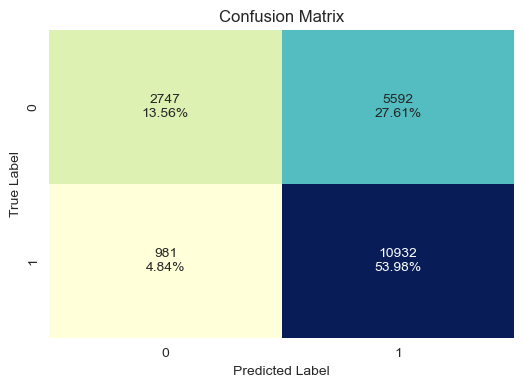

Confusion Matrix for Random Forest on Training Data:


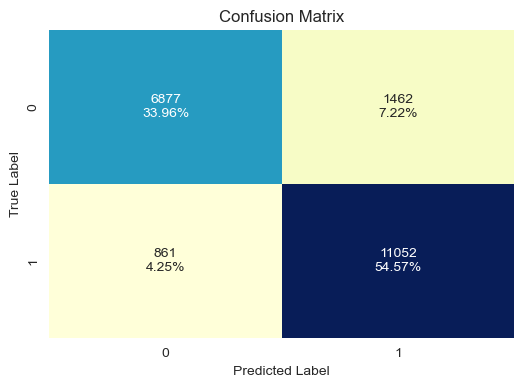

Confusion Matrix for Gradient Boosting on Training Data:


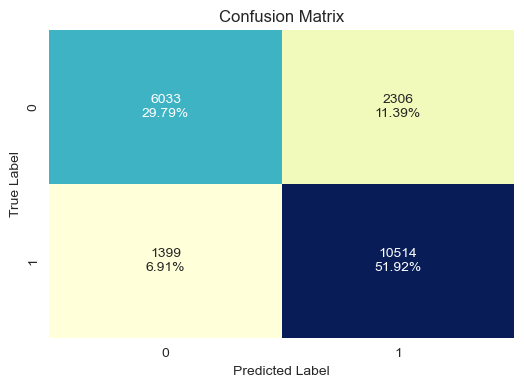

In [ ]:
# Confusion matrix for training data with Hyperparameter tuning
for name, model in tuned_models.items():
    print(f"Confusion Matrix for {name} on Training Data:")
    confusion_matrix_sklearn(model, X_train_oversampled, y_train_oversampled)

Confusion Matrix for AdaBoost on Validation Data:


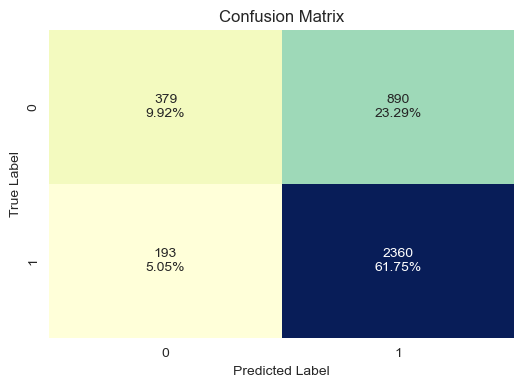

Confusion Matrix for Random Forest on Validation Data:


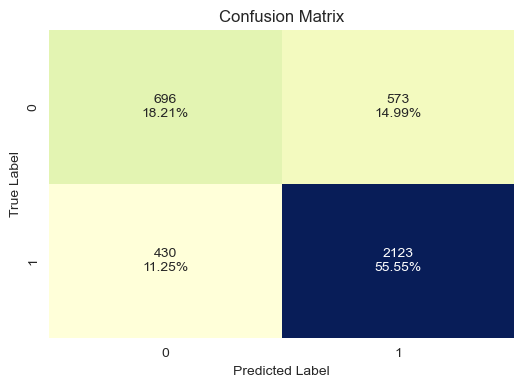

Confusion Matrix for Gradient Boosting on Validation Data:


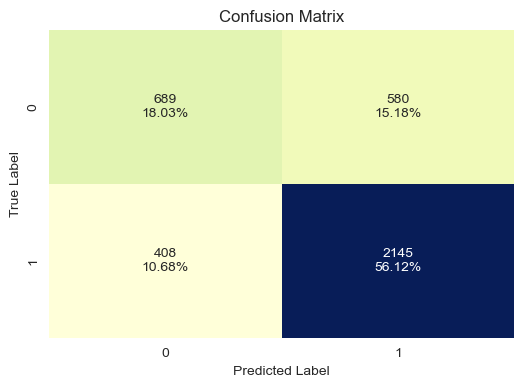

In [ ]:
# Confusion matrix for validation data with Hyperparameter tuning
for name, model in tuned_models.items():
    print(f"Confusion Matrix for {name} on Validation Data:")
    confusion_matrix_sklearn(model, X_val_final, y_val)


In [ ]:
# Summarize and compare the results
df_train_tuned = pd.DataFrame(train_results_tuned).T
df_val_tuned = pd.DataFrame(val_results_tuned).T

# Comparison table
df_comparison_tuned = pd.concat([df_train_tuned['F1'].rename('Train F1'), df_val_tuned['F1'].rename('Validation F1')], axis=1)
df_comparison_tuned['F1 Difference (Train - Val)'] = df_comparison_tuned['Train F1'] - df_comparison_tuned['Validation F1']
df_comparison = df_comparison.sort_values(by='Validation F1', ascending=False)

print("\n--- Training and Validation Set Performance Comparison (GridSearchCV) ---")
print(df_comparison_tuned.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))


--- Training and Validation Set Performance Comparison (GridSearchCV) ---
|                   | Train F1   | Validation F1   | F1 Difference (Train - Val)   |
|:------------------|:-----------|:----------------|:------------------------------|
| AdaBoost          | 0.7689     | 0.8134          | -0.0445                       |
| Random Forest     | 0.9049     | 0.8089          | 0.0960                        |
| Gradient Boosting | 0.8502     | 0.8128          | 0.0374                        |


### Hyperparameter tuning with RandomizedSearchCV

#### Define randomized search parameters

In [ ]:
param_dists = {
    "AdaBoost": {
        "n_estimators": randint(50, 400),
        "learning_rate": uniform(0.01, 0.3)
    },
    "Random Forest": {
        "n_estimators": randint(100, 500),
        "max_depth": [None, 10, 20, 30, 40],
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 5)
    },
    "Gradient Boosting": {
        "n_estimators": randint(100, 400),
        "learning_rate": uniform(0.01, 0.2),
        "max_depth": randint(3, 8)
    }
}

#### Initialize base models

In [ ]:
base_models_rscv = {
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1)
}

#### Performance matrix with Randomized Search

In [ ]:
# Run randomized search SMOTE training data
tuned_models_rscv = {}

for name, model in base_models_rscv.items():
    print(f"\n Running RandomizedSearchCV for {name} ...")
    search_rscv = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dists[name],
        n_iter=30,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    search_rscv.fit(X_train_oversampled, y_train_oversampled)
    tuned_models_rscv[name] = search_rscv.best_estimator_
    print(f"Best Params for {name}: {search_rscv.best_params_}\n")


 Running RandomizedSearchCV for AdaBoost ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params for AdaBoost: {'learning_rate': np.float64(0.3009729556485983), 'n_estimators': 343}


 Running RandomizedSearchCV for Random Forest ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params for Random Forest: {'max_depth': 40, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 164}


 Running RandomizedSearchCV for Gradient Boosting ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params for Gradient Boosting: {'learning_rate': np.float64(0.15226839054973001), 'max_depth': 5, 'n_estimators': 388}



In [ ]:
# Model's performance with RandomizedSearchCV
train_results_rscv, val_results_rscv = {}, {}

for name, model in tuned_models_rscv.items():
  print(f"Training {name}...")

  # Evaluate on Training Set with RandomizedSearchCV
  train_performance_tuned = model_performance_classification_sklearn(model, X_train_oversampled, y_train_oversampled)
  train_results_rscv[name] = train_performance_tuned.iloc[0].to_dict()

  print(f"Training Performance tuned:")
  print(train_results_rscv[name])
  print("\n")

  # Evaluate on Validation Set with RandomizedSearchCV
  val_performance_tuned = model_performance_classification_sklearn(model, X_val_final, y_val)
  val_results_rscv[name] = val_performance_tuned.iloc[0].to_dict()

  print(f"Validation Performance tuned:")
  print(val_results_rscv[name])
  print("\n")

Training AdaBoost...
Training Performance tuned:
{'Accuracy': 0.707386924748173, 'Recall': 0.8368169226894989, 'Precision': 0.7145724320837216, 'F1': 0.7708784410763996}


Validation Performance tuned:
{'Accuracy': 0.7378335949764521, 'Recall': 0.8535056795926361, 'Precision': 0.7762736017100107, 'F1': 0.8130597014925374}


Training Random Forest...
Training Performance tuned:
{'Accuracy': 0.8676180130357496, 'Recall': 0.9109376311592378, 'Precision': 0.8701090442591405, 'F1': 0.8900553619028091}


Validation Performance tuned:
{'Accuracy': 0.7360020931449502, 'Recall': 0.8292205248726988, 'Precision': 0.7869888475836431, 'F1': 0.8075529277131414}


Training Gradient Boosting...
Training Performance tuned:
{'Accuracy': 0.8670254789650405, 'Recall': 0.9173172164861916, 'Precision': 0.8648306426084204, 'F1': 0.8903010305918775}


Validation Performance tuned:
{'Accuracy': 0.7336473050758765, 'Recall': 0.8382295338817078, 'Precision': 0.7795992714025501, 'F1': 0.807852019630049}




Confusion Matrix for AdaBoost on Training Data:


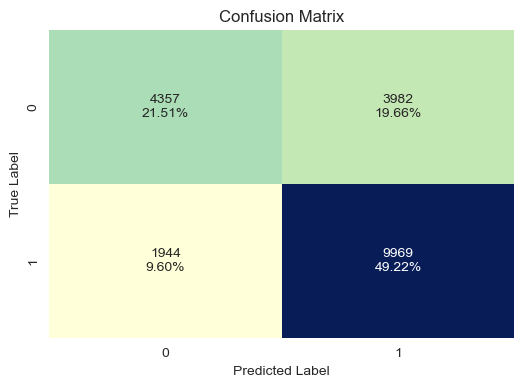

Confusion Matrix for Random Forest on Training Data:


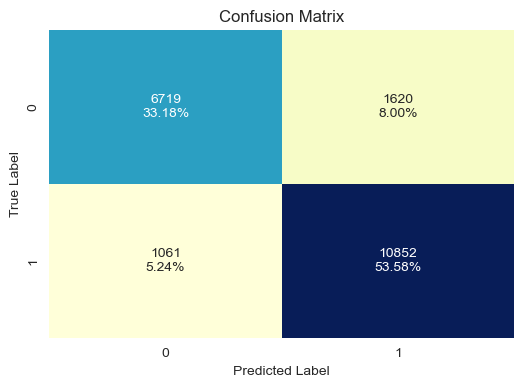

Confusion Matrix for Gradient Boosting on Training Data:


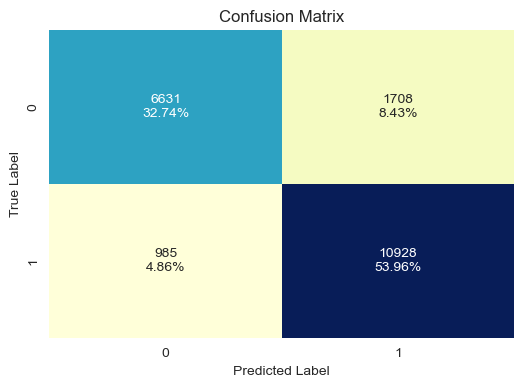

In [ ]:
# Confusion matrix for training data with RandomSearchCV
for name, model in tuned_models_rscv.items():
    print(f"Confusion Matrix for {name} on Training Data:")
    confusion_matrix_sklearn(model, X_train_oversampled, y_train_oversampled)

Confusion Matrix for AdaBoost on Validation Data:


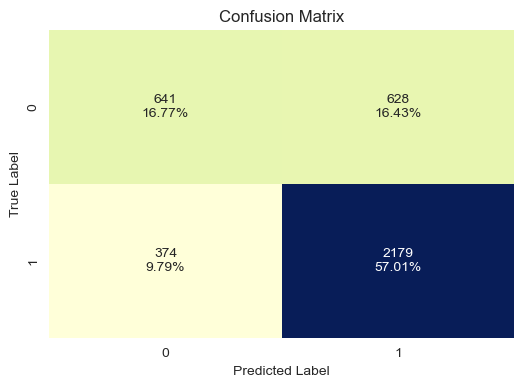

Confusion Matrix for Random Forest on Validation Data:


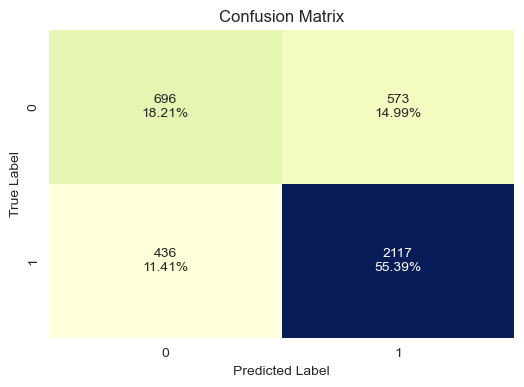

Confusion Matrix for Gradient Boosting on Validation Data:


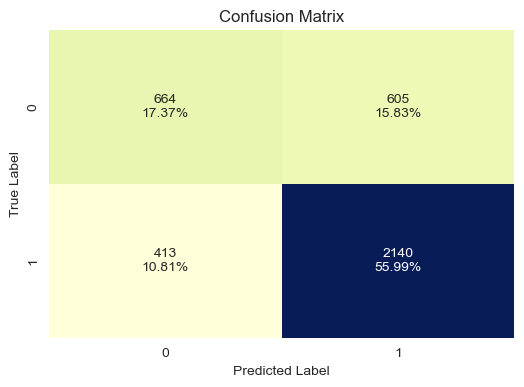

In [ ]:
# Confusion matrix for validation data with RandomSearchCV
for name, model in tuned_models_rscv.items():
    print(f"Confusion Matrix for {name} on Validation Data:")
    confusion_matrix_sklearn(model, X_val_final, y_val)

In [ ]:
# Summarize and compare the results
df_train_rscv = pd.DataFrame(train_results_rscv).T
df_val_rscv = pd.DataFrame(val_results_rscv).T

# Comparison table
df_comparison_rscv = pd.concat([df_train_rscv['F1'].rename('Train F1'), df_val_rscv['F1'].rename('Validation F1')], axis=1)
df_comparison_rscv['F1 Difference (Train - Val)'] = df_comparison_rscv['Train F1'] - df_comparison_rscv['Validation F1']
df_comparison = df_comparison.sort_values(by='Validation F1', ascending=False)

print("\n--- Training and Validation Set Performance Comparison (RandomizedSearchCV) ---")
print(df_comparison_rscv.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))


--- Training and Validation Set Performance Comparison (RandomizedSearchCV) ---
|                   | Train F1   | Validation F1   | F1 Difference (Train - Val)   |
|:------------------|:-----------|:----------------|:------------------------------|
| AdaBoost          | 0.7709     | 0.8131          | -0.0422                       |
| Random Forest     | 0.8901     | 0.8076          | 0.0825                        |
| Gradient Boosting | 0.8903     | 0.8079          | 0.0824                        |


- Validation F1 0.813 in both tuning methods (highest or nearly highest).
- Training F1 lower 0.77, but the small negative F1 difference (-0.04) indicates excellent generalization — no overfitting.
- Performs consistently across GridSearchCV and RandomizedSearchCV → stable and robust.

## Model Performance Summary and Final Model Selection

1. AdaBoost
*  Highest Validation F1-Score (0.8131): AdaBoost achieved the highest performance on the unseen validation data.
*  AdaBoost shows an inverse generalization gap (a negative F1 Difference), meaning its performance is slightly better on the validation set than on the training set.
*  Performs consistently across GridSearchCV and RandomizedSearchCV → stable and robust.
2. Gradient Boosting
*  Validation F1 0.81, also strong, but shows slightly higher training F1 (0.85–0.89) - mild overfitting.
*  Still a very good generalization model, second only to AdaBoost in consistency.
3. Random Forest
*  High training F1 (0.90) but Validation F1 (0.808) — with a relatively large gap (0.09).
*  Indicates overfitting — model fits well on oversampled data but less generalizes to original distribution.
*  Typically performs better with class weight balancing rather than oversampling.

### Final Model Selection

- Final Chosen Model: AdaBoost Classifier (RandomizedSearchCV tuned)
- Best Validation F1 (0.813) — captures minority and majority classes effectively.
- Smallest Train–Validation gap (0.04) — excellent generalization, low variance.
- Consistent performance across both tuning methods — stable, reliable model.
- Lower overfitting risk than RandomForest or GradientBoosting.

### Final Test Evaluation for Tuned AdaBoost Model

In [ ]:
# Combine oversampled training and validation data for final training
X_final_train = pd.concat([X_train_oversampled, X_val_final], axis=0)
y_final_train = pd.concat([y_train_oversampled, y_val], axis=0)

best_ada_params = {
    "n_estimators": tuned_models["AdaBoost"].n_estimators,
    "learning_rate": tuned_models["AdaBoost"].learning_rate
}

print(best_ada_params)

# Refit final AdaBoost model using best params from RandomizedSearchCV
final_ada = AdaBoostClassifier(
    n_estimators=best_ada_params["n_estimators"],
    learning_rate=best_ada_params["learning_rate"],
    random_state=1
)

print("Training Final AdaBoost Model on Combined Data...")
final_ada.fit(X_final_train, y_final_train)

{'n_estimators': 200, 'learning_rate': 0.05}
Training Final AdaBoost Model on Combined Data...


AdaBoostClassifier(learning_rate=0.05, n_estimators=200, random_state=1)

In [ ]:
# Model Performance
final_performance = model_performance_classification_sklearn(final_ada, X_test_final, y_test)

print("Final Model Performance on Test Data:")
print(final_performance)

Final Model Performance on Test Data:
   Accuracy    Recall  Precision       F1
0  0.721612  0.914969   0.733815  0.81444


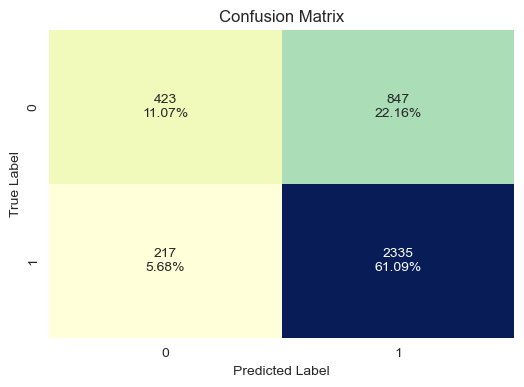

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(final_ada, X_test_final, y_test)

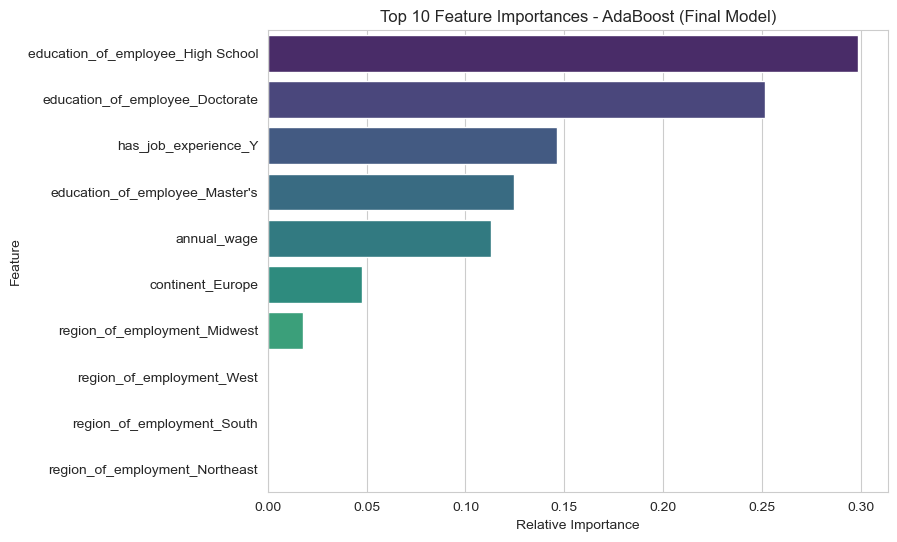

,Feature,Importance
9,education_of_employee_High School,0.298896
8,education_of_employee_Doctorate,0.251490
11,has_job_experience_Y,0.146385
10,education_of_employee_Master's,0.124666
2,annual_wage,0.113133
4,continent_Europe,0.047479
13,region_of_employment_Midwest,0.017952
16,region_of_employment_West,0.000000
15,region_of_employment_South,0.000000
14,region_of_employment_Northeast,0.000000


In [ ]:
# Feature Importances
importances = final_ada.feature_importances_

if len(importances) == X_final_train.shape[1]:
    feature_names = X_final_train.columns
elif len(importances) == X_test.shape[1]:
    feature_names = X_test.columns
else:
    feature_names = [f"Feature_{i}" for i in range(len(importances))]
    print("Feature names not aligned; using generic labels.")

# Build DataFrame safely
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp_df.head(10), x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Feature Importances - AdaBoost (Final Model)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

display(feat_imp_df.head(10))

## Actionable Insights and Recommendations

### Data Insights

* Imbalanced Data:
  * The original dataset showed class imbalance, with a higher number of certified cases than denied ones.

  * SMOTE oversampling helped balance the dataset and improved model generalization.

  * Undersampling, however, led to information loss and lower F1 performance.

* Key Predictors of Visa Certification:
  * Feature importance and statistical analysis indicate that the most influential factors affecting visa certification likelihood are:

  * Prevailing Wage (Yearly basis): Higher annual wages are associated with higher certification rates.

  * Education Level: Applicants with advanced degrees (Master’s, Ph.D.) show higher approval rates for well-paid positions abroad.

  * Job Experience: Candidates with prior work experience have a significantly higher certification probability.

  * Employer Size (no_of_employees): Larger employers tend to have more certified applications, possibly due to better compliance and established visa sponsorship processes.

  * Continent: Applicants from Europe and Africa have slightly higher certification rates compared to other regions.

### Model Evaluation Insights

* Observations:
  * AdaBoost performed nearly equally well on the SMOTE-balanced data, with minimal overfitting (Train–Val difference approximately equal 0.04).

  * Random Forest and Bagging showed mild overfitting due to high model complexity and class imbalance sensitivity.

  * Decision Tree had the highest variance, confirming its unsuitability without regularization or boosting.

### Final Model Recommendation

* Selected Final Model: AdaBoost Classifier (RandomizedSearchCV tuned)
  * Stable and high validation F1 score (0.8131).

  * Minimal overfitting compared to Gradient Boosting.

  * Performs robustly on balanced datasets (important when addressing certification fairness).

  * Simpler and more interpretable ensemble structure than Gradient Boosting.

  * Performs better recall on minority (Denied) cases, aligning with real-world goal of minimizing false approvals.

### Recommendations for Stakeholders

1. **Policy / HR Analytics**
* Prioritize Highly Skilled and Experienced Candidates:
  * Candidates with strong educational backgrounds and proven job experience have a significantly higher certification likelihood.

* Encourage Competitive Compensation Offers:
  * The “unit_of_wage = Year” group shows notably higher approval rates; structured yearly salary offers can improve outcomes.

* Focus on Employer Compliance Readiness:
  * Larger, established employers demonstrate higher success in visa petitions — smaller firms may need guidance on compliance documentation.

2. **Model Deployment**
  * Deploy AdaBoost model as the predictive engine for visa case-status classification.

  * Integrate with workflow tools to:

    * Auto-flag high-risk (potential denial) applications.

    * Provide explainability dashboards showing feature contribution per case.

3. **Continuous Improvement**
  * Automate monthly retraining with recent data to capture new approval patterns or policy changes.

  * Integrate SHAP or LIME explainability to provide transparency to decision-makers.

  * Conduct periodic bias audits to ensure fair predictions across continents, genders, or education levels.

### Summary

- The analysis reveals that visa certification outcomes are strongly influenced by education level, work experience, prevailing wage, and employer size.
- Among multiple models evaluated (Decision Tree, Bagging, Random Forest, Gradient Boosting, and AdaBoost), the tuned AdaBoost classifier (with SMOTE-balanced training data) demonstrated the best balance between predictive accuracy, generalization, and fairness — making it the recommended final model for deployment.